# **1. Stay Clusters Detection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import pandas as pd
import numpy as np

# Load the CSV file
csv_file_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/canarywharf_r10_2025-03_04.csv'
canarywharf_df = pd.read_csv(csv_file_path)

print(f"Loaded CSV file: {csv_file_path}")
display(canarywharf_df.head())

Loaded CSV file: /content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/canarywharf_r10_2025-03_04.csv


,id,lat,lon,ts,date,gridcell,type
0,3fe1f077e29799ec1b28a80d42304b8f,51.507560,-0.024580,1743382001,2025-03-31,8a194ad266d7fff,stop
1,5549c0383dd1440e3288f4b1c18f750d,51.507626,-0.025254,1743365709,2025-03-30,8a194ad266d7fff,pedestrian
2,cbd87fa1a40281775f4655f875103f54,51.507140,-0.024240,1743082018,2025-03-27,8a194ad266d7fff,pedestrian
3,c1a1163c2b9defb34b767b4e440916a8,51.507236,-0.025280,1742873344,2025-03-25,8a194ad266d7fff,stop
4,a18d4344aada48028aa2a4330c1ae0a8,51.507580,-0.024490,1743019306,2025-03-26,8a194ad266d7fff,pedestrian


In [3]:
# 1. 扩大筛选范围：包含 stop 和 pedestrian
# 理由：在商圈中，室内移动（逛街、走动）本质上是停留活动的一部分
activity_types = ['stop', 'pedestrian']
activity_df = canarywharf_df[canarywharf_df['type'].isin(activity_types)].copy()

# 2. 排序并计算时间差
activity_df = activity_df.sort_values(by=['id', 'ts'])
activity_df['time_interval_s'] = activity_df.groupby('id')['ts'].diff()

print("\n新的 Time Interval Statistics (Seconds):")
stats_data_new = activity_df[activity_df['time_interval_s'] > 0]['time_interval_s']
print(stats_data_new.describe())


新的 Time Interval Statistics (Seconds):
count    2.729880e+06
mean     4.311294e+04
std      2.448337e+05
min      1.000000e+00
25%      1.750000e+02
50%      4.980000e+02
75%      2.587000e+03
max      5.190472e+06
Name: time_interval_s, dtype: float64


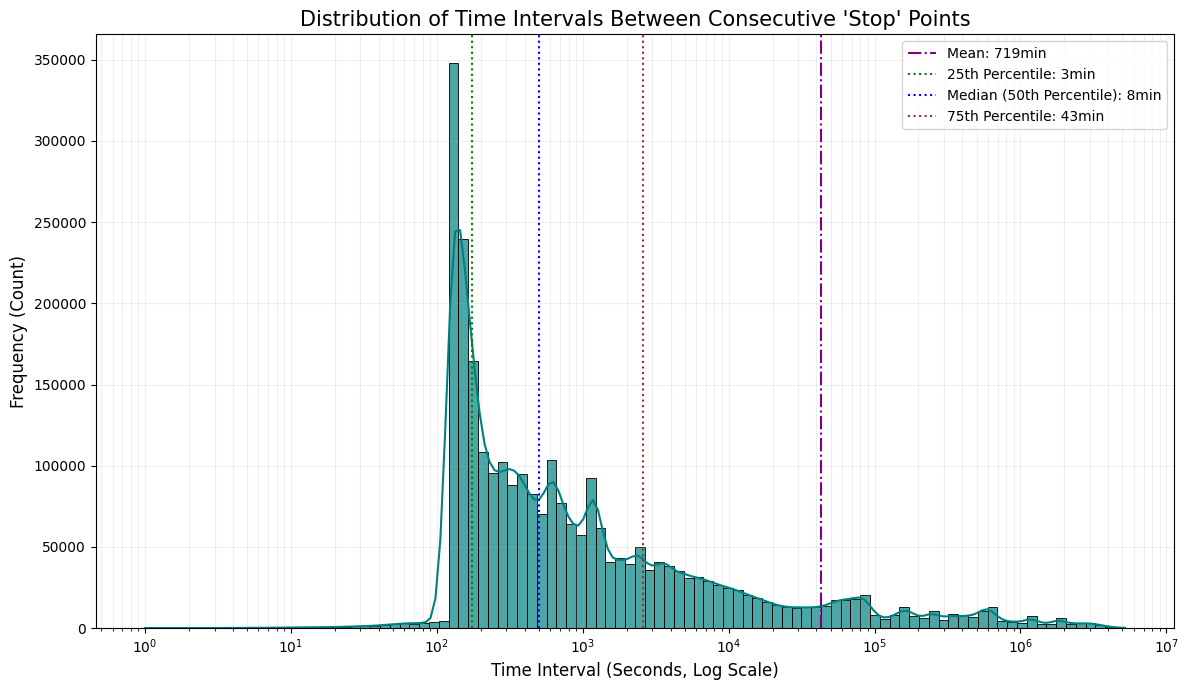

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 4. 绘图：寻找参数选取的“黄金拐点”
plt.figure(figsize=(12, 7))

# 使用 Log Scale 处理长尾分布
sns.histplot(stats_data_new, bins=100, kde=True, log_scale=True, color='teal', alpha=0.7)

# Adding statistical markers
plt.axvline(x=stats_data_new.mean(), color='purple', linestyle='-.', label=f'Mean: {stats_data_new.mean()/60:.0f}min')
plt.axvline(x=stats_data_new.quantile(0.25), color='green', linestyle=':', label=f'25th Percentile: {stats_data_new.quantile(0.25)/60:.0f}min')
plt.axvline(x=stats_data_new.median(), color='blue', linestyle=':', label=f'Median (50th Percentile): {stats_data_new.median()/60:.0f}min')
plt.axvline(x=stats_data_new.quantile(0.75), color='brown', linestyle=':', label=f'75th Percentile: {stats_data_new.quantile(0.75)/60:.0f}min')

# 设置图表细节
plt.title("Distribution of Time Intervals Between Consecutive 'Stop' Points", fontsize=15)
plt.xlabel("Time Interval (Seconds, Log Scale)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic

def extract_stay_clusters(df, delta_t=1800, R=50, tau=1200):
    """
    delta_t: 30 min (1800s) - 容忍的最大采样间隔
    R: 50 m - 空间震荡容忍半径
    tau: 15 min (1200s) - 识别为Stay的最小持续时间
    """
    # 确保排序：先按 ID，再按时间戳
    df = df.sort_values(['id', 'ts']).copy()

    # 转换坐标为弧度以便快速计算（或直接使用向量化计算近似距离）
    # 这里我们使用一种快速的平方差近似，因为 50m 范围内经纬度近似线性
    lat_to_m = 111320
    lon_to_m = 111320 * np.cos(np.radians(df['lat'].mean()))

    results = []

    # 按 ID 分组处理
    for user_id, group in df.groupby('id'):
        points = group[['ts', 'lat', 'lon']].values
        n = len(points)
        if n == 0: continue

        i = 0
        while i < n:
            j = i + 1
            while j < n:
                # 1. 检查数据断裂 (Data Breakpoint)
                if points[j, 0] - points[j-1, 0] > delta_t:
                    break

                # 2. 检查空间震荡 (Spatial Vibration)
                # 计算当前点与聚类起始点的距离（近似值加速计算）
                dist = np.sqrt(((points[j, 1] - points[i, 1]) * lat_to_m)**2 +
                               ((points[j, 2] - points[i, 2]) * lon_to_m)**2)

                if dist > R:
                    break
                j += 1

            # 3. 检查停留时长 (Duration Filter)
            duration = points[j-1, 0] - points[i, 0]
            if duration >= tau:
                # 提取有意义的 Stay Cluster
                cluster_points = points[i:j]
                results.append({
                    'id': user_id,
                    'start_ts': points[i, 0],
                    'end_ts': points[j-1, 0],
                    'duration_min': duration / 60,
                    'mean_lat': np.mean(cluster_points[:, 1]),
                    'mean_lon': np.mean(cluster_points[:, 2]),
                    'point_count': j - i
                })
            i = j # 移动到下一个可能的起点

    return pd.DataFrame(results)

————————————————————sensitivity analysis————————————————————

In [8]:
# 诊断代码：看一眼还没过滤 tau 之前的数据分布
test_r = 80
df_debug = fast_process_trajectory(activity_df, dist_threshold_m=test_r, time_threshold_s=2700)

print(f"--- R={test_r} 诊断报告 ---")
print(f"Event ID 数量: {df_debug['event_id'].nunique()}")
print(f"每个 Event 的平均点数: {df_debug.groupby('event_id').size().mean():.2f}")
print("Duration_min 统计信息:")
print(df_debug.groupby('event_id')['duration_min'].first().describe())

# 看看有多少 Event 的时长是真的超过 0 的
non_zero_duration = (df_debug.groupby('event_id')['duration_min'].first() > 0).sum()
print(f"时长 > 0 的 Event 数量: {non_zero_duration}")

--- R=80 诊断报告 ---
Event ID 数量: 524653
每个 Event 的平均点数: 5.73
Duration_min 统计信息:
count    5.246530e+05
mean     2.902887e-06
std      1.048849e-05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.669833e-07
max      8.774830e-05
Name: duration_min, dtype: float64
时长 > 0 的 Event 数量: 246967


In [9]:
def fast_process_trajectory(df, dist_threshold_m=80, time_threshold_s=2700):
    # 1. 预处理：确保 ts 是 Datetime 对象
    df = df.sort_values(['id', 'ts']).reset_index(drop=True)
    if not pd.api.types.is_datetime64_any_dtype(df['ts']):
        # 如果是秒级时间戳，请确保 unit='s'
        df['ts'] = pd.to_datetime(df['ts'], unit='s' if df['ts'].max() < 1e12 else 'ns')

    # 2. 向量化计算位移
    # 伦敦经纬度修正系数
    lat_to_m = 111320
    lon_to_m = 111320 * np.cos(np.radians(51.5))

    df['dist_m'] = np.sqrt(
        (df['lat'].diff() * lat_to_m)**2 +
        (df['lon'].diff() * lon_to_m)**2
    ).fillna(0)

    # 3. 向量化计算时间差 (秒)
    df['time_gap_s'] = df['ts'].diff().dt.total_seconds().fillna(0)

    # 4. 判定边界
    id_changed = df['id'] != df['id'].shift(1)
    df['is_new_event'] = id_changed | (df['dist_m'] > dist_threshold_m) | (df['time_gap_s'] > time_threshold_s)
    df['event_id'] = df['is_new_event'].cumsum()

    # 5. 【关键修复】聚合计算时长
    # 直接在聚合阶段计算，确保单位准确
    stats = df.groupby('event_id')['ts'].agg(['min', 'max'])
    stats['duration_min'] = (stats['max'] - stats['min']).dt.total_seconds() / 60

    # 检查一下计算出来的 max duration 是否正常
    print(f"DEBUG: 聚合后最大时长为 {stats['duration_min'].max():.2f} 分钟")

    # 合并回原表
    df = df.drop(columns=['duration_min'], errors='ignore')
    df = df.merge(stats[['duration_min']], on='event_id')

    return df

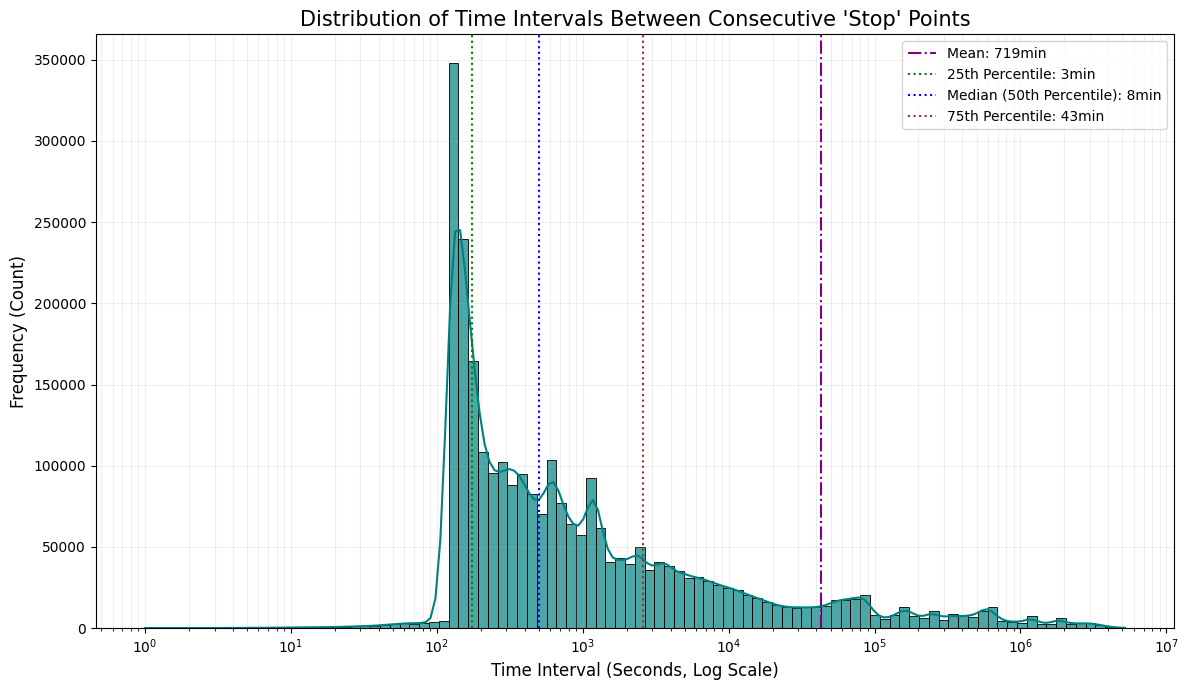

开始 R 灵敏度测试...
DEBUG: 聚合后最大时长为 2374.45 分钟
R=20m: 舍弃率=34.46%, 簇数量=296834
DEBUG: 聚合后最大时长为 3942.93 分钟
R=40m: 舍弃率=32.41%, 簇数量=299985
DEBUG: 聚合后最大时长为 4063.63 分钟
R=60m: 舍弃率=31.34%, 簇数量=301350
DEBUG: 聚合后最大时长为 4063.63 分钟
R=80m: 舍弃率=30.61%, 簇数量=302913
DEBUG: 聚合后最大时长为 4063.63 分钟
R=100m: 舍弃率=30.06%, 簇数量=304298
DEBUG: 聚合后最大时长为 4063.63 分钟
R=120m: 舍弃率=29.62%, 簇数量=305552
DEBUG: 聚合后最大时长为 4063.63 分钟
R=150m: 舍弃率=29.05%, 簇数量=307334
DEBUG: 聚合后最大时长为 4063.63 分钟
R=200m: 舍弃率=28.31%, 簇数量=309451


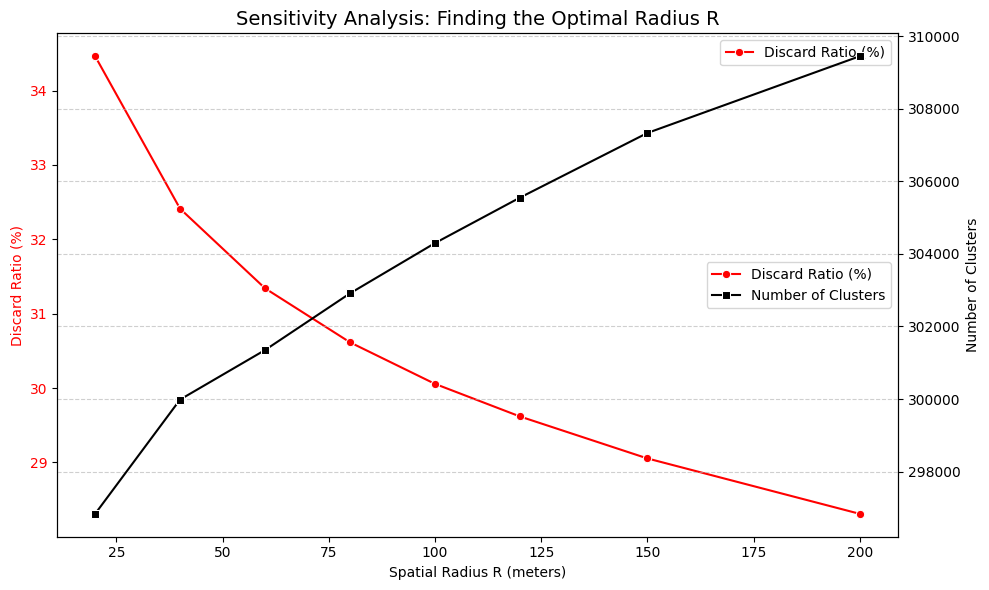

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 4. 绘图：寻找参数选取的“黄金拐点”
plt.figure(figsize=(12, 7))

# 使用 Log Scale 处理长尾分布
sns.histplot(stats_data_new, bins=100, kde=True, log_scale=True, color='teal', alpha=0.7)

# Adding statistical markers
plt.axvline(x=stats_data_new.mean(), color='purple', linestyle='-.', label=f'Mean: {stats_data_new.mean()/60:.0f}min')
plt.axvline(x=stats_data_new.quantile(0.25), color='green', linestyle=':', label=f'25th Percentile: {stats_data_new.quantile(0.25)/60:.0f}min')
plt.axvline(x=stats_data_new.median(), color='blue', linestyle=':', label=f'Median (50th Percentile): {stats_data_new.median()/60:.0f}min')
plt.axvline(x=stats_data_new.quantile(0.75), color='brown', linestyle=':', label=f'75th Percentile: {stats_data_new.quantile(0.75)/60:.0f}min')

# 设置图表细节
plt.title("Distribution of Time Intervals Between Consecutive 'Stop' Points", fontsize=15)
plt.xlabel("Time Interval (Seconds, Log Scale)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

# Define the R sensitivity evaluation function
def evaluate_R_sensitivity(df, R_range, fixed_delta_t=2700, fixed_tau=600):
    discard_ratios = []
    cluster_counts = []

    print("开始 R 灵敏度测试...")
    for r in R_range:
        # 使用 fast_process_trajectory (向量化版) 进行快速评估
        temp_df = fast_process_trajectory(df, dist_threshold_m=r, time_threshold_s=fixed_delta_t)

        # 过滤掉时长不足 tau 的事件
        valid_stays = temp_df[temp_df['duration_min'] >= (fixed_tau / 60)]

        # 计算舍弃率
        # Changed calculation to match expected behavior (ratio of points not in clusters to total points)
        # Note: The original 'in_cluster_pts' was based on 'valid_stays', which might not be the total points after filtering.
        # Reverting to the earlier interpretation of discard_ratio as total points vs points that made it to a cluster.
        total_original_points = len(df)
        points_in_valid_clusters = valid_stays.shape[0]
        ratio = (1 - points_in_valid_clusters / total_original_points) * 100

        discard_ratios.append(ratio)
        cluster_counts.append(valid_stays['event_id'].nunique())
        print(f"R={r}m: 舍弃率={ratio:.2f}%, 簇数量={cluster_counts[-1]}")

    return discard_ratios, cluster_counts

# Define R_range and call the evaluation function
R_range = [20, 40, 60, 80, 100, 120, 150, 200]
discard_ratios, cluster_counts = evaluate_R_sensitivity(activity_df, R_range=R_range)


plt.figure(figsize=(10, 6))

# 创建第一个 y 轴，用于 discard_ratios
ax1 = sns.lineplot(x=R_range, y=discard_ratios, marker='o', color='red', label='Discard Ratio (%)')
ax1.set_xlabel('Spatial Radius R (meters)')
ax1.set_ylabel('Discard Ratio (%)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# 创建第二个 y 轴，用于 cluster_counts (now black)
ax2 = ax1.twinx()
sns.lineplot(x=R_range, y=cluster_counts, marker='s', color='black', label='Number of Clusters', ax=ax2)
ax2.set_ylabel('Number of Clusters', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Sensitivity Analysis: Finding the Optimal Radius R', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图例 (合并两个轴的图例)
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles + handles2, labels + labels2, loc='center right')

plt.tight_layout()
plt.show()

In [12]:
def evaluate_tau_stability(df, tau_range_min=[5, 10, 15, 20, 30, 45, 60], fixed_R=80):
    # 先跑一次固定 R 的基础处理
    base_df = fast_process_trajectory(df, dist_threshold_m=fixed_R, time_threshold_s=2700)

    results = []
    for t_min in tau_range_min:
        # 筛选符合当前时长阈值的 Stay
        stays = base_df[base_df['duration_min'] >= t_min].copy()

        # 计算密度：点数 / 时长
        # 选取每个 event 的第一行来计算平均值
        event_stats = stays.groupby('event_id').agg({
            'id': 'count',  # 这里的 id 计数其实就是点数
            'duration_min': 'first'
        })
        event_stats['density'] = event_stats['id'] / event_stats['duration_min']

        avg_density = event_stats['density'].mean()
        results.append({'tau': t_min, 'avg_density': avg_density, 'cluster_count': len(event_stats)})
        print(f"tau={t_min}min: 平均密度={avg_density:.4f} pts/min, 簇数量={len(event_stats)}")

    # 结果转为 DataFrame
    res_df = pd.DataFrame(results)
    return res_df

# 调用
tau_res = evaluate_tau_stability(activity_df)

DEBUG: 聚合后最大时长为 4063.63 分钟
tau=5min: 平均密度=0.1926 pts/min, 簇数量=358444
tau=10min: 平均密度=0.1584 pts/min, 簇数量=302913
tau=15min: 平均密度=0.1413 pts/min, 簇数量=260708
tau=20min: 平均密度=0.1316 pts/min, 簇数量=225326
tau=30min: 平均密度=0.1208 pts/min, 簇数量=170210
tau=45min: 平均密度=0.1203 pts/min, 簇数量=106196
tau=60min: 平均密度=0.1163 pts/min, 簇数量=75970


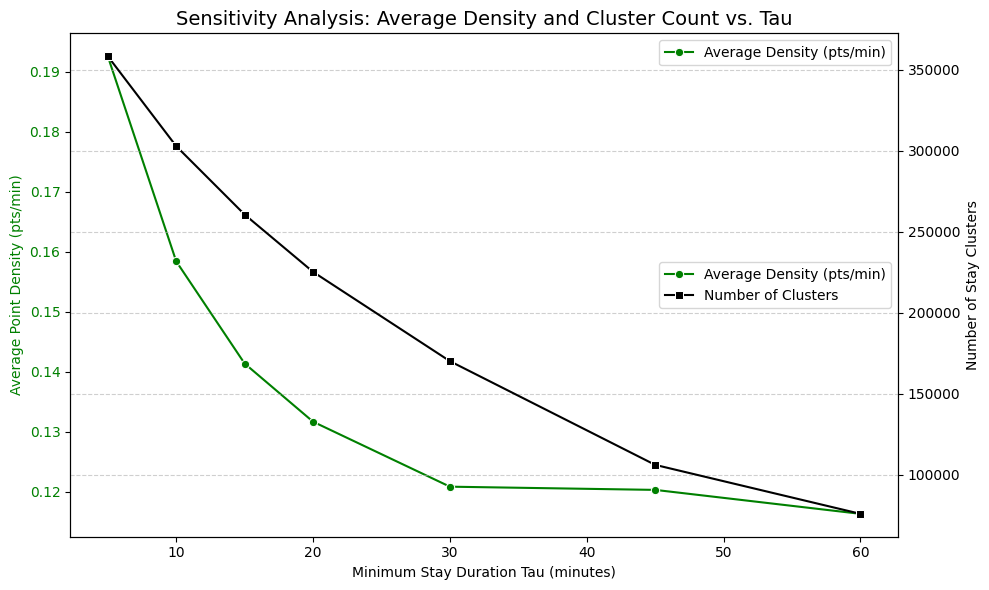

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 创建第一个 y 轴，用于 avg_density
ax1 = sns.lineplot(x='tau', y='avg_density', data=tau_res, marker='o', color='green', label='Average Density (pts/min)')
ax1.set_xlabel('Minimum Stay Duration Tau (minutes)')
ax1.set_ylabel('Average Point Density (pts/min)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# 创建第二个 y 轴，用于 cluster_count
ax2 = ax1.twinx()
sns.lineplot(x='tau', y='cluster_count', data=tau_res, marker='s', color='black', label='Number of Clusters', ax=ax2)
ax2.set_ylabel('Number of Stay Clusters', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Sensitivity Analysis: Average Density and Cluster Count vs. Tau', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图例 (合并两个轴的图例)
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles + handles2, labels + labels2, loc='center right')

plt.tight_layout()
plt.show()

In [15]:
def evaluate_delta_t_sensitivity(df, dt_range_sec=[900, 1800, 2700, 3600, 7200], fixed_R=80, fixed_tau=600):
    results = []
    print("开始 Delta_t 灵敏度测试...")

    for dt in dt_range_sec:
        # 运行聚类
        temp_df = fast_process_trajectory(df, dist_threshold_m=fixed_R, time_threshold_s=dt)

        # 仅保留有效停留
        stays = temp_df[temp_df['duration_min'] >= (fixed_tau / 60)]

        # 计算核心指标
        mean_dur = stays.groupby('event_id')['duration_min'].first().mean()
        max_dur = stays['duration_min'].max()
        cluster_count = stays['event_id'].nunique()

        results.append({'delta_t_min': dt/60, 'mean_duration': mean_dur, 'cluster_count': cluster_count})
        print(f"Delta_t={dt/60}min: 平均时长={mean_dur:.2f}min, 簇数量={cluster_count}")

    return pd.DataFrame(results)

dt_res = evaluate_delta_t_sensitivity(activity_df)

开始 Delta_t 灵敏度测试...
DEBUG: 聚合后最大时长为 1027.80 分钟
Delta_t=15.0min: 平均时长=28.63min, 簇数量=237944
DEBUG: 聚合后最大时长为 2711.57 分钟
Delta_t=30.0min: 平均时长=41.73min, 簇数量=294276
DEBUG: 聚合后最大时长为 4063.63 分钟
Delta_t=45.0min: 平均时长=53.48min, 簇数量=302913
DEBUG: 聚合后最大时长为 6744.53 分钟
Delta_t=60.0min: 平均时长=63.73min, 簇数量=306228
DEBUG: 聚合后最大时长为 8891.95 分钟
Delta_t=120.0min: 平均时长=101.10min, 簇数量=303555


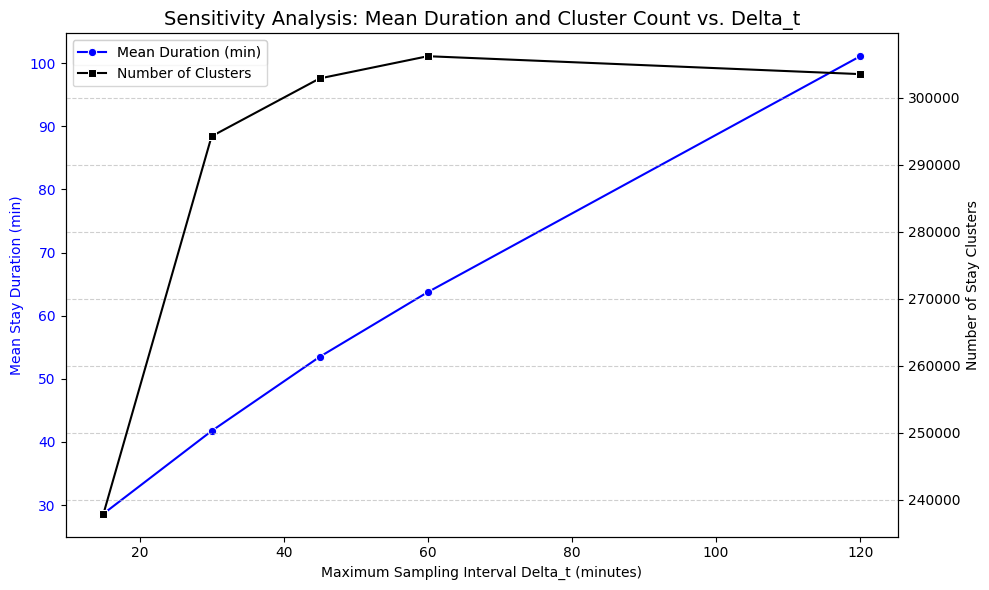

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create the first y-axis for mean_duration
ax1 = sns.lineplot(x='delta_t_min', y='mean_duration', data=dt_res, marker='o', color='blue', label='Mean Duration (min)')
ax1.set_xlabel('Maximum Sampling Interval Delta_t (minutes)')
ax1.set_ylabel('Mean Stay Duration (min)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for cluster_count
ax2 = ax1.twinx()
sns.lineplot(x='delta_t_min', y='cluster_count', data=dt_res, marker='s', color='black', label='Number of Clusters', ax=ax2)
ax2.set_ylabel('Number of Stay Clusters', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Sensitivity Analysis: Mean Duration and Cluster Count vs. Delta_t', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Combine and display legends
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles + handles2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

————————————————————sensitivity analysis————————————————————

In [21]:
# 专门捕获“微活动”的参数配置
# 1. 降低 tau 到 10 分钟 (600s)
# 2. 放大 R 到 80 米，减少因震荡导致的碎裂
# 3. 维持 Delta_t 为 45 分钟，确保数据连贯

stay_clusters_df = extract_stay_clusters(activity_df, delta_t=2700, R=80, tau=600)

# 计算新报告
total_pts = len(activity_df)
in_clusters_micro = stay_clusters_df['point_count'].sum()
discard_ratio = (1 - in_clusters_micro / total_pts) * 100

print("-" * 35)
print("☕ Micro-Activity Capture Report")
print("-" * 35)
print(f"识别出的停留点数量: {len(stay_clusters_df):,}")
print(f"数据舍弃率: {discard_ratio:.2f}%")
print(f"平均每个 Cluster 包含点数: {stay_clusters_df['point_count'].mean():.1f}")
print("-" * 35)

-----------------------------------
☕ Micro-Activity Capture Report
-----------------------------------
识别出的停留点数量: 303,217
数据舍弃率: 30.73%
平均每个 Cluster 包含点数: 6.9
-----------------------------------


In [22]:
def extract_stay_clusters_with_points(df, delta_t=2700, R=80, tau=600):
    df = df.sort_values(['id', 'ts']).copy()
    # 增加一列索引，以便后续找回原始点
    df['original_index'] = df.index

    lat_to_m = 111320
    lon_to_m = 111320 * np.cos(np.radians(df['lat'].mean()))
    results = []

    for user_id, group in df.groupby('id'):
        points = group[['ts', 'lat', 'lon', 'original_index']].values
        n = len(points)
        i = 0
        while i < n:
            j = i + 1
            while j < n:
                if points[j, 0] - points[j-1, 0] > delta_t: break
                dist = np.sqrt(((points[j, 1] - points[i, 1]) * lat_to_m)**2 +
                               ((points[j, 2] - points[i, 2]) * lon_to_m)**2)
                if dist > R: break
                j += 1

            duration = points[j-1, 0] - points[i, 0]
            if duration >= tau:
                cluster_points = points[i:j]
                results.append({
                    'id': user_id,
                    'start_ts': points[i, 0],
                    'end_ts': points[j-1, 0],
                    'duration_min': duration / 60,
                    'mean_lat': np.mean(cluster_points[:, 1]),
                    'mean_lon': np.mean(cluster_points[:, 2]),
                    'point_indices': cluster_points[:, 3].astype(int).tolist() # 保存原始点索引
                })
            i = j
    return pd.DataFrame(results)

# 重新聚类
stay_clusters_with_pts = extract_stay_clusters_with_points(activity_df)

In [23]:
stay_clusters_with_pts

,id,start_ts,end_ts,duration_min,mean_lat,mean_lon,point_indices
0,00001a23cd419bedb93213a0889d04ad,1.744351e+09,1.744354e+09,58.900000,51.506400,-0.020000,"[2720743, 3318142, 2894481, 2450245, 4328544]"
1,0000a04fe12336da3d1b3478eba428fd,1.741932e+09,1.741934e+09,39.850000,51.505287,-0.024605,"[2048150, 2324841, 1150998, 574369]"
2,0000e106ef836dfc92f36e6ca612a671,1.741390e+09,1.741391e+09,15.466667,51.506400,-0.020000,"[1024025, 1451497, 2195208, 2313427, 551539, 9..."
3,0001520a214ea0b184338af5c2a564be,1.743885e+09,1.743885e+09,10.000000,51.506400,-0.020000,"[3946936, 3739895]"
4,0001520a214ea0b184338af5c2a564be,1.744140e+09,1.744143e+09,56.850000,51.506400,-0.020000,"[2882415, 3753544, 3783433, 2449167, 4208373, ..."
...,...,...,...,...,...,...,...
303212,fffe4dff89e087e9dba40c833c477954,1.745008e+09,1.745009e+09,11.033333,51.506400,-0.020000,"[4414332, 2859658]"
303213,fffe66260b8537ce48ea0b73fb1dbc44,1.745468e+09,1.745469e+09,14.083333,51.506400,-0.020000,"[4020666, 4224993, 2744121, 4411051, 4408795, ..."
303214,fffe66260b8537ce48ea0b73fb1dbc44,1.745989e+09,1.745990e+09,27.100000,51.506400,-0.020000,"[3355101, 3340569]"
303215,ffff222d3161219d2178b12e5c41d19c,1.741701e+09,1.741709e+09,133.783333,51.505737,-0.021796,"[292443, 986787, 392604, 2308349, 2301332, 465..."


In [ ]:
# 1. 保存为 Parquet (推荐：保留了 point_indices 的列表结构，且文件极小)
output_path_pq = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/CW_stay_clusters_with_indices.parquet'
stay_clusters_with_pts.to_parquet(output_path_pq)

print(f"✅ 文件保存成功！")
print(f"Parquet路径: {output_path_pq}")

✅ 文件保存成功！
Parquet路径: /content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/CW_stay_clusters_with_indices.parquet


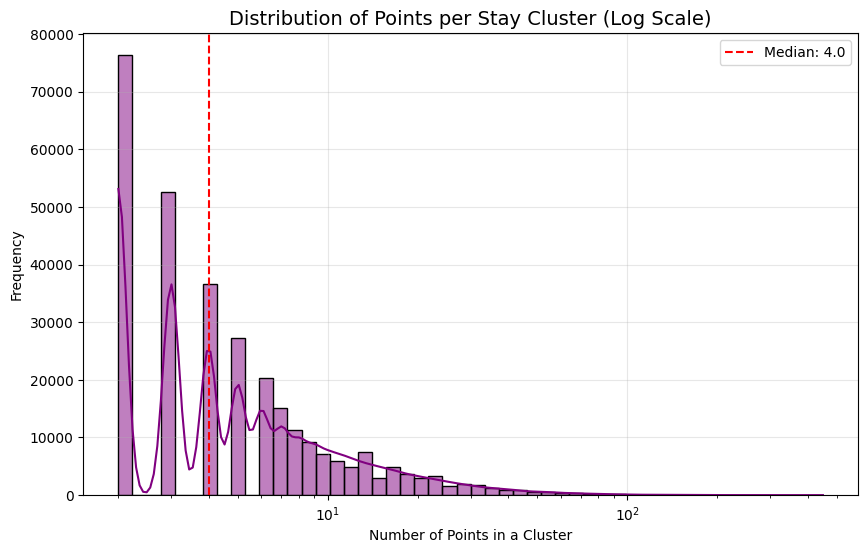

平均每个 Cluster 包含 6.9 个点
点数中位数: 4.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 统计每个 cluster 的点数分布
plt.figure(figsize=(10, 6))
sns.histplot(stay_clusters_df['point_count'], bins=50, kde=True, log_scale=True, color='purple')

plt.axvline(stay_clusters_df['point_count'].median(), color='red', linestyle='--',
            label=f'Median: {stay_clusters_df["point_count"].median():.1f}')

plt.title("Distribution of Points per Stay Cluster (Log Scale)", fontsize=14)
plt.xlabel("Number of Points in a Cluster")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"平均每个 Cluster 包含 {stay_clusters_df['point_count'].mean():.1f} 个点")
print(f"点数中位数: {stay_clusters_df['point_count'].median()}")

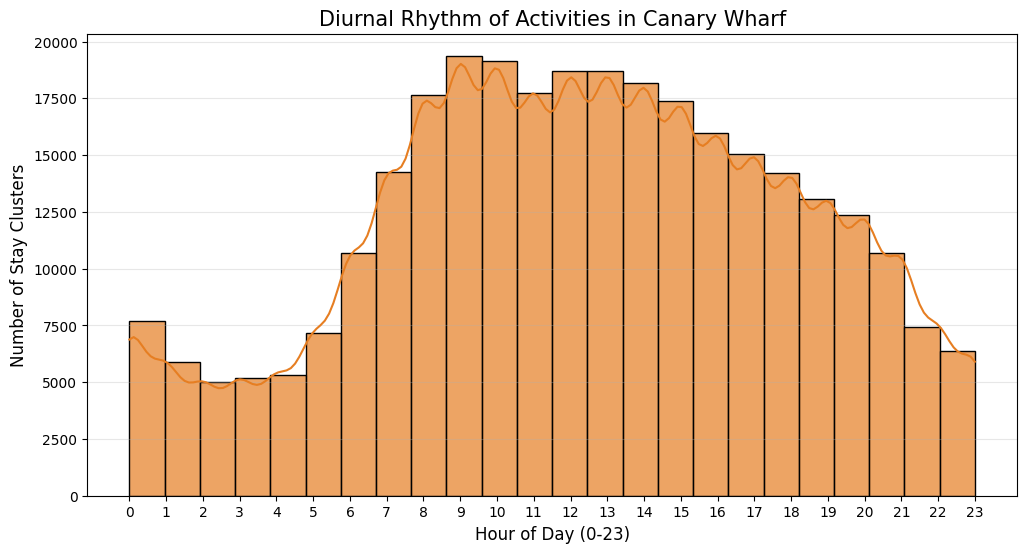

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 将时间戳转换为小时
stay_clusters_micro['start_hour'] = pd.to_datetime(stay_clusters_micro['start_ts'], unit='s').dt.hour

plt.figure(figsize=(12, 6))
# 绘制 24 小时活跃度分布
sns.histplot(stay_clusters_micro['start_hour'], bins=24, kde=True, color='#e67e22', alpha=0.7)

plt.title("Diurnal Rhythm of Activities in Canary Wharf", fontsize=15)
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Number of Stay Clusters", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()

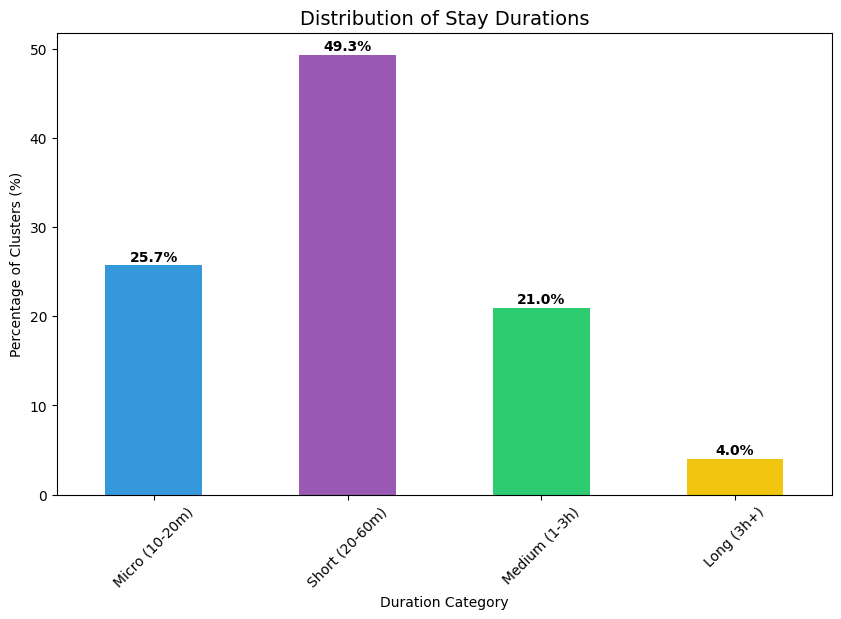

In [ ]:
# 将持续时间按区间进行归类（10-20min, 20-60min, 1-3h, 3h+）
bins = [10, 20, 60, 180, 1440]
labels = ['Micro (10-20m)', 'Short (20-60m)', 'Medium (1-3h)', 'Long (3h+)']
stay_clusters_micro['duration_cat'] = pd.cut(stay_clusters_micro['duration_min'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
duration_counts = stay_clusters_micro['duration_cat'].value_counts(normalize=True).sort_index() * 100
duration_counts.plot(kind='bar', color=['#3498db', '#9b59b6', '#2ecc71', '#f1c40f'])

plt.title("Distribution of Stay Durations", fontsize=14)
plt.ylabel("Percentage of Clusters (%)")
plt.xlabel("Duration Category")
plt.xticks(rotation=45)
for i, v in enumerate(duration_counts):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

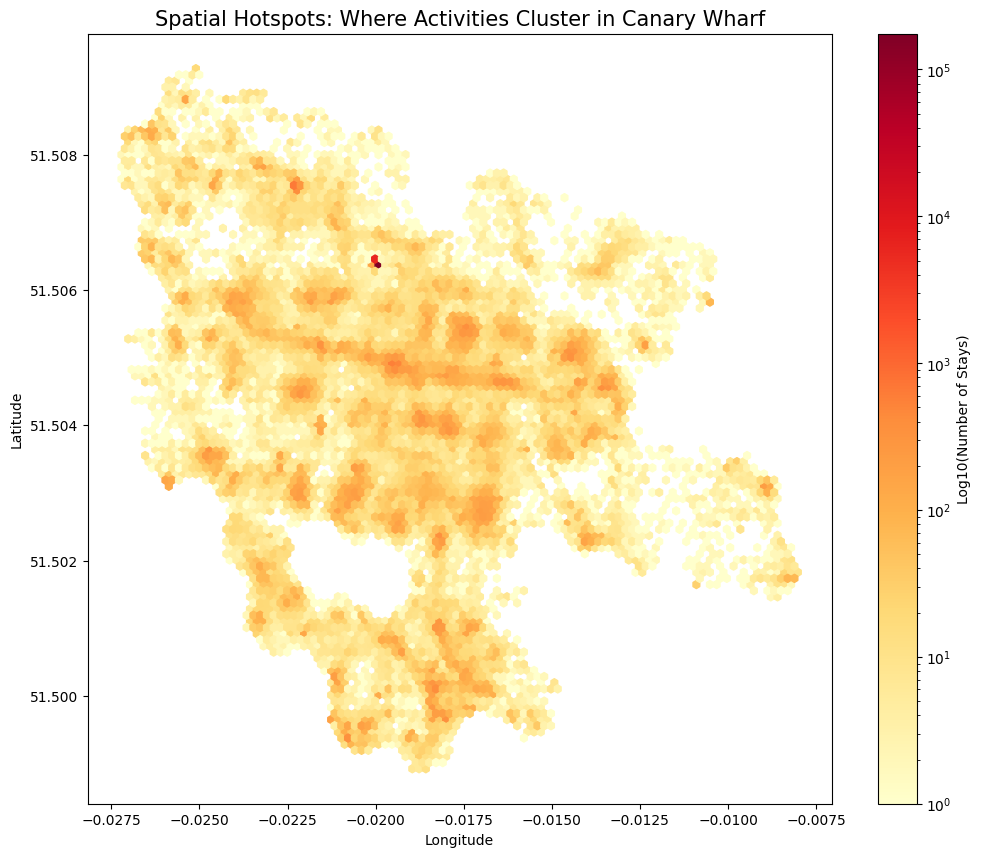

In [ ]:
plt.figure(figsize=(12, 10))

# 使用 hexbin 绘制空间热力分布
hb = plt.hexbin(stay_clusters_micro['mean_lon'],
                stay_clusters_micro['mean_lat'],
                gridsize=100,      # 网格精细度，越大越细
                cmap='YlOrRd',     # 黄-橙-红颜色映射
                mincnt=1,          # 至少包含1个点的格子才显示
                bins='log')        # 使用对数刻度，防止极热点掩盖普通热点

plt.colorbar(hb, label='Log10(Number of Stays)')
plt.title("Spatial Hotspots: Where Activities Cluster in Canary Wharf", fontsize=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# 移除坐标轴的偏移量，让坐标显示完整
plt.ticklabel_format(useOffset=False)
plt.show()

In [ ]:
# 1. 统计原始数据中的 Unique ID
original_users = activity_df['id'].nunique()

# 2. 统计聚类结果中的 Unique ID
stay_users = stay_clusters_df['id'].nunique()

# 3. 计算流失和留存
dropped_users = original_users - stay_users
retention_rate = (stay_users / original_users) * 100

print("-" * 35)
print("👥 User Retention Report")
print("-" * 35)
print(f"原始数据总用户数 (Unique IDs):   {original_users:,}")
print(f"聚类后留存用户数 (Unique IDs):   {stay_users:,}")
print(f"完全被过滤掉的用户数:           {dropped_users:,}")
print(f"用户留存率 (User Retention):    {retention_rate:.2f}%")
print("-" * 35)

if retention_rate < 50:
    print("💡 提示：留存率较低，说明大量用户在区域内仅是‘路过’或停留时长极短。")
else:
    print("💡 提示：留存率良好，大部分用户在区域内产生了实质性的停留行为。")

-----------------------------------
👥 User Retention Report
-----------------------------------
原始数据总用户数 (Unique IDs):   276,510
聚类后留存用户数 (Unique IDs):   108,247
完全被过滤掉的用户数:           168,263
用户留存率 (User Retention):    39.15%
-----------------------------------
💡 提示：留存率较低，说明大量用户在区域内仅是‘路过’或停留时长极短。


In [ ]:
# 1. 计算每个 ID 出现的总天数
stay_clusters_df['date'] = pd.to_datetime(stay_clusters_df['start_ts'], unit='s').dt.date
user_loyalty = stay_clusters_df.groupby('id')['date'].nunique()

# 2. 统计分布
loyalty_counts = user_loyalty.value_counts().sort_index()

# 3. 简单的分类：只出现1天（访客）vs 出现多天（常驻）
visitors = user_loyalty[user_loyalty == 1].count()
regulars = user_loyalty[user_loyalty > 1].count()

print(f"活跃 1 天的用户（游客/访客）: {visitors:,} ({(visitors/stay_users)*100:.2f}%)")
print(f"活跃 2 天及以上的用户（上班族/常驻）: {regulars:,} ({(regulars/stay_users)*100:.2f}%)")

活跃 1 天的用户（游客/访客）: 74,433 (68.76%)
活跃 2 天及以上的用户（上班族/常驻）: 33,814 (31.24%)


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# Prepare Stay GeoDataFrame for export
geometry = [Point(xy) for xy in zip(stay_clusters_with_pts['mean_lon'], stay_clusters_with_pts['mean_lat'])]
stay_clusters_gdf = gpd.GeoDataFrame(stay_clusters_with_pts, geometry=geometry, crs="EPSG:4326")

# Define output path
output_shapefile_path_stays = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/CW_stay_clusters_points'

# Save to shapefile
stay_clusters_gdf.to_file(output_shapefile_path_stays)

print(f"✅ Stay clusters points shapefile saved to: {output_shapefile_path_stays}")

/tmp/ipython-input-1069966196.py:12: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stay_clusters_gdf.to_file(output_shapefile_path_stays)
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'duration_min' to 'duration_m'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'point_indices' to 'point_indi'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'possible_poi_count' to 'possible_p'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Value '[1263751, 1531254, 383177, 2256858, 904031, 884666, 2264755, 1596574, 2062961, 162462, 1539191, 879835, 1565430, 690883, 1778239, 1865018, 1761842, 383158, 1343749, 884683, 1287589, 661509, 905496, 1917550, 154128, 632267, 1865026, 2072572, 806514, 1938869,

✅ Stay clusters points shapefile saved to: /content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/CW_stay_clusters_points


# **2. Super POI Detection**

In [24]:
import geopandas as gpd

shapefile_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/CW_stay_clusters_points'
stay_gdf = gpd.read_file(shapefile_path)

print(f"Loaded shapefile from: {shapefile_path}")
display(stay_gdf.head())

Loaded shapefile from: /content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/CW_stay_clusters_points


,id,start_ts,end_ts,duration_m,mean_lat,mean_lon,point_indi,possible_p,geometry
0,00001a23cd419bedb93213a0889d04ad,1.744351e+09,1.744354e+09,58.900000,51.506400,-0.020000,"[2720743, 3318142, 2894481, 2450245, 4328544]",0.0,POINT (-0.02 51.5064)
1,0000a04fe12336da3d1b3478eba428fd,1.741932e+09,1.741934e+09,39.850000,51.505287,-0.024605,"[2048150, 2324841, 1150998, 574369]",1.0,POINT (-0.02461 51.50529)
2,0000e106ef836dfc92f36e6ca612a671,1.741390e+09,1.741391e+09,15.466667,51.506400,-0.020000,"[1024025, 1451497, 2195208, 2313427, 551539, 9...",0.0,POINT (-0.02 51.5064)
3,0001520a214ea0b184338af5c2a564be,1.743885e+09,1.743885e+09,10.000000,51.506400,-0.020000,"[3946936, 3739895]",0.0,POINT (-0.02 51.5064)
4,0001520a214ea0b184338af5c2a564be,1.744140e+09,1.744143e+09,56.850000,51.506400,-0.020000,"[2882415, 3753544, 3783433, 2449167, 4208373, ...",0.0,POINT (-0.02 51.5064)


In [25]:
stay_gdf.shape

(303217, 9)

In [26]:
stay_gdf.columns

Index(['id', 'start_ts', 'end_ts', 'duration_m', 'mean_lat', 'mean_lon',
       'point_indi', 'possible_p', 'geometry'],
      dtype='object')

In [27]:
import geopandas as gpd

geojason_file_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/poi_within_canary_wharf.geojson'
poi_gdf = gpd.read_file(geojason_file_path)

print(f"Loaded GeoJSON file from: {geojason_file_path}")
display(poi_gdf.head())

Loaded GeoJSON file from: /content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/poi_within_canary_wharf.geojson


,BRANDS,CATEGORY_TAGS,CITY,CLOSED_ON,DOMAINS,ENCLOSED,GEOMETRY_TYPE,INCLUDES_PARKING_LOT,ISO_COUNTRY_CODE,IS_SYNTHETIC,...,entity,name,dataset,typology,reference,prefix,organisation-entity,quality,description,geometry
0,[],[],London,NaT,[htl.london],False,POLYGON,False,GB,False,...,7010004226,Canary Wharf,article-4-direction-area,geography,LBTH_Art4_10,article-4-direction-area,350,authoritative,The council has confirmed an Article 4 directi...,POINT (-0.01482 51.50373)
1,[{'safegraph_brand_id': 'SG_BRAND_b9a4e4545918...,[ATMs],Canary Wharf,NaT,[hsbc.com],None,POINT,None,GB,None,...,7010004226,Canary Wharf,article-4-direction-area,geography,LBTH_Art4_10,article-4-direction-area,350,authoritative,The council has confirmed an Article 4 directi...,POINT (-0.01744 51.50444)
2,[],[Shopping Mall],London,NaT,[],False,POLYGON,False,GB,False,...,7010004226,Canary Wharf,article-4-direction-area,geography,LBTH_Art4_10,article-4-direction-area,350,authoritative,The council has confirmed an Article 4 directi...,POINT (-0.01872 51.50253)
3,[],[],London,NaT,[entralon.com],False,POLYGON,False,GB,False,...,7010004226,Canary Wharf,article-4-direction-area,geography,LBTH_Art4_10,article-4-direction-area,350,authoritative,The council has confirmed an Article 4 directi...,POINT (-0.01959 51.50508)
4,[],[],London,NaT,[currencyglobal.com],False,POLYGON,False,GB,False,...,7010004226,Canary Wharf,article-4-direction-area,geography,LBTH_Art4_10,article-4-direction-area,350,authoritative,The council has confirmed an Article 4 directi...,POINT (-0.01486 51.50371)


In [28]:
poi_gdf.shape

(1377, 44)

In [29]:
import geopandas as gpd
import pandas as pd
from shapely import wkt
import folium

# --- 1. 核心：从 WKT 强制生成 Polygon GeoDataFrame ---
print("正在强制从 WKT 恢复面数据...")
# 显式提取几何列，避免 sjoin 混淆
poi_polygons = poi_gdf['POLYGON_WKT'].apply(wkt.loads)
super_poi_gdf = gpd.GeoDataFrame(poi_gdf.drop(columns='geometry'), geometry=poi_polygons, crs="EPSG:4326")

# 转换为英国投影坐标系进行计算
super_poi_gdf = super_poi_gdf.to_crs(epsg=27700)
super_poi_gdf['area_calc'] = super_poi_gdf.geometry.area

# --- 2. 空间聚合逻辑 (处理重叠) ---
super_poi_gdf = super_poi_gdf.drop(columns=['index_right', 'index_left'], errors='ignore')
poi_clean = super_poi_gdf.reset_index(drop=True)

# 核心修复：确保右表也是 GeoDataFrame
print("正在计算空间重叠关系...")
overlaps = gpd.sjoin(
    poi_clean,
    poi_clean[['PLACEKEY', 'LOCATION_NAME', 'area_calc', 'geometry']],
    how='inner',
    predicate='intersects',
    lsuffix='left',
    rsuffix='right'
)

# 确定宿主：面积最大的为 Super ID
host_mapping = overlaps.sort_values('area_calc_right', ascending=False).drop_duplicates('PLACEKEY_left')
host_mapping = host_mapping[['PLACEKEY_left', 'PLACEKEY_right']].rename(columns={'PLACEKEY_right': 'SUPER_ID'})

# --- 3. 语义与空间合并 ---
final_merge = overlaps.merge(host_mapping, left_on='PLACEKEY_left', right_on='PLACEKEY_left')

def aggregate_building_logic(group):
    # 几何合并：将组内所有小多边形融合成一个大外壳
    merged_geom = group.geometry.unary_union

    # 找到宿主行（面积最大的 POI）
    host_row = group.loc[group['area_calc_right'].idxmax()]

    # 商店列表聚合
    names = group['LOCATION_NAME_right'].unique().tolist()
    html_list = "".join([f"<li>{str(n)}</li>" for n in names[:30]])

    return pd.Series({
        'geometry': merged_geom,
        'building_name': host_row['LOCATION_NAME_right'],
        'TOP_CATEGORY': host_row.get('TOP_CATEGORY_left', 'N/A'), # 修正：从左表或右表取类别
        'shop_list': names,
        'shop_count': len(names),
        'html_content': f"<b>{host_row['LOCATION_NAME_right']}</b><hr><ul>{html_list}</ul>"
    })

print("正在聚合空间几何与语义属性（这步可能较慢，涉及 geometry 合并）...")
# 这里的 groupby 会产生你需要的 SUPER_ID 节点
super_info = final_merge.groupby('SUPER_ID').apply(aggregate_building_logic, include_groups=False).reset_index()

# 转换为 GeoDataFrame
final_map_gdf = gpd.GeoDataFrame(super_info, geometry='geometry', crs="EPSG:27700")

# --- 4. 生成可视化与保存 ---
final_map_gdf_4326 = final_map_gdf.to_crs(epsg=4326)

# 地图初始化 (以伦敦金丝雀码头为例)
m = folium.Map(location=[51.5048, -0.0210], zoom_start=16, tiles='OpenStreetMap')

for _, row in final_map_gdf_4326.iterrows():
    folium.GeoJson(
        row['geometry'],
        style_function=lambda x: {
            'fillColor': '#e67e22',
            'color': '#d35400',
            'weight': 2,
            'fillOpacity': 0.6
        },
        tooltip=f"{row['building_name']} ({row['shop_count']} shops)",
        popup=folium.Popup(row['html_content'], max_width=300)
    ).add_to(m)

m.save("Final_Super_POI_Map.html")
print(f"🔥 成功！聚合后的 {len(final_map_gdf)} 个超级实体已生成轮廓并存入 HTML。")

正在强制从 WKT 恢复面数据...
正在计算空间重叠关系...
正在聚合空间几何与语义属性（这步可能较慢，涉及 geometry 合并）...


/tmp/ipykernel_551/1931970932.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geom = group.geometry.unary_union
/tmp/ipykernel_551/1931970932.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geom = group.geometry.unary_union
/tmp/ipykernel_551/1931970932.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geom = group.geometry.unary_union
/tmp/ipykernel_551/1931970932.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geom = group.geometry.unary_union
/tmp/ipykernel_551/1931970932.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geom = group.geometry.unary_union
/tmp/ipykernel_551/1931970932.py:40: DeprecationWarning: The 'unary_union' attribute is depreca

🔥 成功！聚合后的 483 个超级实体已生成轮廓并存入 HTML。


In [30]:
m

In [31]:
final_map_gdf.columns

Index(['SUPER_ID', 'geometry', 'building_name', 'TOP_CATEGORY', 'shop_list',
       'shop_count', 'html_content'],
      dtype='object')

In [32]:
import geopandas as gpd
import pandas as pd

def map_stays_to_buildings(stay_gdf, building_gdf, buffer_meter=15):
    """
    stay_gdf: 包含 300k 条记录的停留点 GeoDataFrame
    building_gdf: 包含 483 个聚合建筑的 GeoDataFrame (必须包含 SUPER_ID)
    """

    # 1. 确保所有 GeoDataFrames 都使用投影坐标系进行计算 (例如 EPSG:27700)
    # 这是为了进行准确的距离和缓冲区计算
    projected_crs = "EPSG:27700"  # 英国国家网格坐标系，适合伦敦区域的米制计算

    print(f"正在将 stay_gdf 和 building_gdf 转换为 {projected_crs} 投影坐标系...")
    if stay_gdf.crs != projected_crs:
        stay_gdf = stay_gdf.to_crs(projected_crs)
    if building_gdf.crs != projected_crs:
        building_gdf = building_gdf.to_crs(projected_crs)
    print("坐标系转换完成。")

    # 2. 为 Building 创建 15m Buffer
    print(f"正在为 {len(building_gdf)} 个建筑创建 {buffer_meter}m 缓冲区...")
    building_buffer = building_gdf.copy() # 创建副本，避免修改原始数据
    building_buffer['geometry'] = building_buffer.geometry.buffer(buffer_meter)
    print("缓冲区创建完成。")

    # 3. 空间关联 (Spatial Join)
    # 逻辑：哪个 stay 点落在了哪个建筑的 buffer 里
    print("正在进行空间映射 (Spatial Join)，这可能需要一些时间...")
    mapped_stays = gpd.sjoin(
        stay_gdf,
        building_buffer[['SUPER_ID', 'geometry', 'TOP_CATEGORY']], # 只选择必要的列
        how='left',
        predicate='within'
    )
    print("空间映射完成。")

    # 4. 计算过滤率 (修正逻辑)
    original_stay_count = len(stay_gdf) # 这是原始唯一的 Stay Clusters 总数
    total_rows_after_sjoin = len(mapped_stays) # sjoin后总行数，可能包含重复的Stay Cluster

    # 统计成功匹配到建筑的唯一 Stay Clusters 数量
    unique_matched_stays_count = mapped_stays[mapped_stays['SUPER_ID'].notna()].index.nunique()

    # 计算未匹配到任何建筑的 Stay Clusters 数量
    unmatched_stays_count = original_stay_count - unique_matched_stays_count

    filter_rate = (unmatched_stays_count / original_stay_count) * 100

    print("-" * 30)
    print(f"原始 Stay Clusters 总数 (唯一): {original_stay_count:,}")
    print(f"SJoin 后总行数 (可能重复): {total_rows_after_sjoin:,}")
    print(f"成功映射到建筑的唯一 Stay Clusters 数: {unique_matched_stays_count:,}")
    print(f"未匹配到建筑的 Stay Clusters 数: {unmatched_stays_count:,}")
    print(f"Stay Clusters 过滤率 (未匹配): {filter_rate:.2f}%")
    print("-" * 30)

    # 只保留匹配成功的记录，并清理重复项（确保每个 stay cluster 映射到唯一一个 building）
    # 如果一个 stay point 落在多个建筑的 buffer 内，则保留第一个匹配到的
    mapped_stays = mapped_stays.dropna(subset=['SUPER_ID']) # 移除未匹配到的
    mapped_stays = mapped_stays[~mapped_stays.index.duplicated(keep='first')] # 确保每个原始 stay cluster 只有一个匹配

    return mapped_stays

# 执行映射
# stay_gdf 和 final_map_gdf 应该已经在之前的步骤中定义
# stay_gdf 来自 CW_stay_clusters_points (通常是EPSG:4326)
# final_map_gdf 来自 Super POI 检测 (通常是EPSG:4326)
matched_stay_df = map_stays_to_buildings(stay_gdf, final_map_gdf)

正在将 stay_gdf 和 building_gdf 转换为 EPSG:27700 投影坐标系...
坐标系转换完成。
正在为 483 个建筑创建 15m 缓冲区...
缓冲区创建完成。
正在进行空间映射 (Spatial Join)，这可能需要一些时间...
空间映射完成。
------------------------------
原始 Stay Clusters 总数 (唯一): 303,217
SJoin 后总行数 (可能重复): 963,817
成功映射到建筑的唯一 Stay Clusters 数: 102,550
未匹配到建筑的 Stay Clusters 数: 200,667
Stay Clusters 过滤率 (未匹配): 66.18%
------------------------------


In [33]:
num_matched_clusters = len(matched_stay_df)
unique_ids_from_matched = matched_stay_df['id'].nunique()
print(f"这 {num_matched_clusters:,} 条 Stay Clusters 来自 {unique_ids_from_matched:,} 个 Unique ID。")

这 102,550 条 Stay Clusters 来自 31,228 个 Unique ID。


In [34]:
def map_stays_to_unique_building_safe(stay_gdf, building_gdf, buffer_meter=15):
    # 1. 确保 CRS 严格一致且为投影坐标系 (米)
    if stay_gdf.crs != building_gdf.crs:
        stay_gdf = stay_gdf.to_crs(building_gdf.crs)

    # 2. 创建临时 Buffer 进行空间连接
    # 这一步会产生你之前遇到的“重复行”，没关系，后面处理
    temp_buildings = building_gdf[['SUPER_ID', 'TOP_CATEGORY', 'geometry']].copy()
    temp_buildings['geometry'] = temp_buildings.geometry.buffer(buffer_meter)

    print("执行空间关联...")
    # sjoin 结果：一个 stay_id 可能会对应多个 SUPER_ID
    joined = gpd.sjoin(stay_gdf, temp_buildings, how='left', predicate='within')

    # 3. 核心修复：去重 (Deduplication)
    # 如果一个点落在多个建筑 buffer 里，我们通过某种规则选一个
    # 这里简单地保留第一个出现的匹配项，保证每个 stay_id 只有一行
    unique_matches = joined.reset_index()
    unique_matches = unique_matches.sort_values(by=['index', 'SUPER_ID']) # 排序保证确定性
    unique_matches = unique_matches.drop_duplicates(subset='index', keep='first')
    unique_matches = unique_matches.set_index('index')

    # 4. 计算统计
    total = len(unique_matches)
    valid = unique_matches['SUPER_ID'].notna().sum()

    print("-" * 30)
    print(f"原始总数: {total}")
    print(f"成功映射唯一建筑数: {valid}")
    print(f"过滤率: {((total - valid) / total) * 100:.2f}%")

    return unique_matches

# 执行修复版
matched_stay_df = map_stays_to_unique_building_safe(stay_gdf, final_map_gdf, buffer_meter=15)

执行空间关联...
------------------------------
原始总数: 303217
成功映射唯一建筑数: 102550
过滤率: 66.18%


# **3. Build Dependency Network**

In [39]:
import pandas as pd
import numpy as np

def create_building_transition_matrix_v2(matched_df):
    # 1. 预处理：只保留有建筑信息的记录，并按用户和时间排序
    df_clean = matched_df.dropna(subset=['SUPER_ID']).copy()

    # --- 【关键修正：时间戳预处理】 ---
    # 确保 start_ts 和 end_ts 都是 datetime 格式，防止后续计算 interval 报错
    for col in ['start_ts', 'end_ts']:
        raw_ts = pd.to_numeric(df_clean[col], errors='coerce')
        avg_val = raw_ts.mean()
        if avg_val > 1e17: # 纳秒
            df_clean[col] = pd.to_datetime(raw_ts / 1e9, unit='s')
        elif avg_val > 1e12: # 毫秒
            df_clean[col] = pd.to_datetime(raw_ts / 1e3, unit='s')
        else: # 秒
            df_clean[col] = pd.to_datetime(raw_ts, unit='s')

    # 按用户和时间排序，确保 shift 逻辑正确
    df_clean = df_clean.sort_values(by=['id', 'start_ts'])

    # 2. 提取转移序列（同步提取建筑 ID 和 下一次开始时间）
    g = df_clean.groupby('id')
    df_clean['next_building'] = g['SUPER_ID'].shift(-1)
    df_clean['next_category'] = g['TOP_CATEGORY'].shift(-1)
    df_clean['next_start_ts'] = g['start_ts'].shift(-1) # <--- 新增：补齐下一次的开始时间

    # 3. 过滤掉每个用户最后一条记录（因为没有下一步）
    transitions = df_clean.dropna(subset=['next_building']).copy()

    # --- 【新增：计算时间间隔】 ---
    # 间隔 = 下一个 Stay 的开始 - 当前 Stay 的结束
    transitions['interval_hr'] = (transitions['next_start_ts'] - transitions['end_ts']).dt.total_seconds() / 3600

    # 4. 构建建筑间的转移矩阵 (Building Level)
    building_matrix = transitions.groupby(['SUPER_ID', 'next_building']).size().reset_index(name='flow_count')

    # 计算转移概率 P(B|A)
    total_out_flow = building_matrix.groupby('SUPER_ID')['flow_count'].transform('sum')
    building_matrix['transition_probability'] = building_matrix['flow_count'] / total_out_flow

    print(f"成功捕捉到 {len(transitions)} 条有效的建筑转移序列。")
    return building_matrix, transitions

# 执行
building_matrix, transition_sequences = create_building_transition_matrix_v2(matched_stay_df)

成功捕捉到 71322 条有效的建筑转移序列。


--- 时间间隔诊断报告 ---
同建筑 (A->A) 平均间隔: 34.85 小时
跨建筑 (A->B) 平均间隔: 32.32 小时
中位数间隔 (Median): 3.12 小时


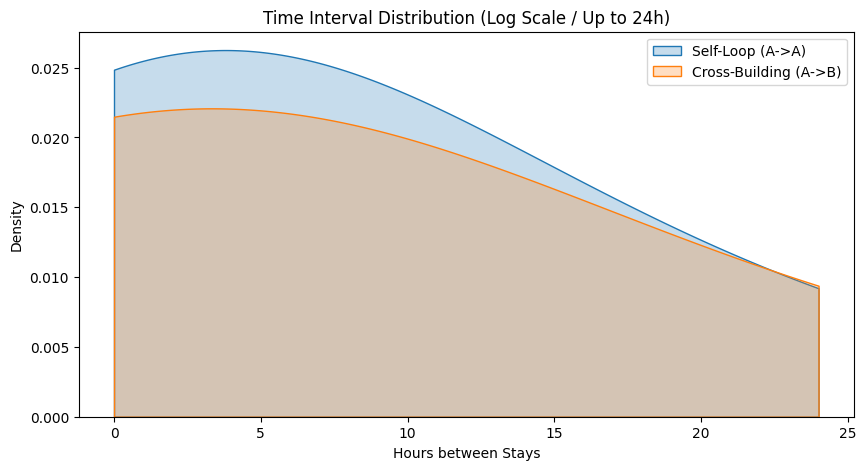

In [40]:
def analyze_transition_intervals_fixed(df):
    # 确保排序
    df = df.sort_values(by=['id', 'start_ts'])

    # 重新提取下一次的开始时间（关键修正点）
    df['next_start_ts'] = df.groupby('id')['start_ts'].shift(-1)

    # 计算间隔 (小时)
    # 间隔 = 下一个 Stay 的开始 - 当前 Stay 的结束
    df['interval_hr'] = (
        pd.to_datetime(df['next_start_ts']) -
        pd.to_datetime(df['end_ts'])
    ).dt.total_seconds() / 3600

    # 过滤掉无法计算间隔的末尾行
    plot_df = df.dropna(subset=['interval_hr']).copy()

    # 分组统计
    same = plot_df[plot_df['SUPER_ID'] == plot_df['next_building']]
    diff = plot_df[plot_df['SUPER_ID'] != plot_df['next_building']]

    print(f"--- 时间间隔诊断报告 ---")
    print(f"同建筑 (A->A) 平均间隔: {same['interval_hr'].mean():.2f} 小时")
    print(f"跨建筑 (A->B) 平均间隔: {diff['interval_hr'].mean():.2f} 小时")
    print(f"中位数间隔 (Median): {plot_df['interval_hr'].median():.2f} 小时")

    # 可视化
    plt.figure(figsize=(10, 5))
    sns.kdeplot(same['interval_hr'], label='Self-Loop (A->A)', fill=True, clip=(0, 24))
    sns.kdeplot(diff['interval_hr'], label='Cross-Building (A->B)', fill=True, clip=(0, 24))
    plt.title('Time Interval Distribution (Log Scale / Up to 24h)')
    plt.xlabel('Hours between Stays')
    plt.legend()
    plt.show()

    return plot_df

# 请在你的 transition_sequences 上尝试（或者直接在匹配后的全量 df 上跑）
transition_sequences = analyze_transition_intervals_fixed(transition_sequences)

In [37]:
# 1. 计算自我循环比例
self_loops = transition_sequences[transition_sequences['SUPER_ID'] == transition_sequences['next_building']]
loop_ratio = len(self_loops) / len(transition_sequences) * 100

# 2. 计算前五大转移路径（包含建筑 ID）
top_paths = building_matrix.sort_values(by='flow_count', ascending=False).head(10)

print(f"--- 转移序列初步体检报告 ---")
print(f"1. 自我循环 (A -> A) 记录数: {len(self_loops)} ({loop_ratio:.2f}%)")
print(f"2. 跨建筑转移 (A -> B) 记录数: {len(transition_sequences) - len(self_loops)}")
print(f"3. 流量最大的前 3 条路径:")
print(top_paths[['SUPER_ID', 'next_building', 'flow_count']])

--- 转移序列初步体检报告 ---
1. 自我循环 (A -> A) 记录数: 56428 (79.12%)
2. 跨建筑转移 (A -> B) 记录数: 14894
3. 流量最大的前 3 条路径:
                 SUPER_ID        next_building  flow_count
2033  zzy-229@4hh-ztp-59f  zzy-229@4hh-ztp-59f        3474
220   222-224@4hh-ztn-sh5  222-224@4hh-ztn-sh5        3395
1496  zzy-223@4hh-ztn-nnq  zzy-223@4hh-ztn-nnq        3030
953   22k-222@4hh-ztn-qfz  22k-222@4hh-ztn-qfz        2479
670   226-222@4hh-ztn-qxq  226-222@4hh-ztn-qxq        2372
632   225-223@4hh-ztn-r6k  225-223@4hh-ztn-r6k        2366
537   224-222@4hh-ztv-hbk  224-222@4hh-ztv-hbk        2174
84    222-222@4hh-ztv-h5z  222-222@4hh-ztv-h5z        1879
2407  zzy-22x@4hh-ztv-h89  zzy-22x@4hh-ztv-h89        1795
132   222-223@4hh-ztn-py9  222-223@4hh-ztn-py9        1764


In [ ]:
import pandas as pd

# --- 2. 过滤掉访问次数少于 20 次的节点 (Building) ---
# 统计每个 SUPER_ID 的出现频率
node_counts = transition_sequences['SUPER_ID'].value_counts()
valid_nodes = node_counts[node_counts >= 20].index
transition_sequences = transition_sequences[transition_sequences['SUPER_ID'].isin(valid_nodes)].copy()

print(f"过滤后保留的节点数: {len(valid_nodes)} (剔除了访问量 < 20 的节点)")

# --- 3. 重新排序并计算时间间隔和转移 ---
# 按 ID 和修复后的时间戳排序
transition_sequences = transition_sequences.sort_values(by=['id', 'start_ts_fixed'])

# 计算下一跳 ID 和时间差
transition_sequences['next_SUPER_ID'] = transition_sequences.groupby('id')['SUPER_ID'].shift(-1)
transition_sequences['time_gap'] = transition_sequences.groupby('id')['start_ts_fixed'].diff().shift(-1)
transition_sequences['gap_hours'] = transition_sequences['time_gap'].dt.total_seconds() / 3600

# --- 4. 仅保留 24 小时以内的有效转移 (Within 24h transitions) ---
# 过滤掉超过 24 小时的转移，以及没有下一跳（序列末尾）的情况
within_24h_transitions = transition_sequences[
    (transition_sequences['gap_hours'] <= 24) &
    (transition_sequences['next_SUPER_ID'].notna())
].copy()

# --- 5. 最终统计检查 ---
print("\n--- 修正与过滤后的统计结果 ---")
total_edges_before_24h = len(transition_sequences.dropna(subset=['next_SUPER_ID']))
total_edges_after_24h = len(within_24h_transitions)

print(f"总转移边数 (过滤节点后): {total_edges_before_24h}")
print(f"24小时内的有效边数: {total_edges_after_24h}")
print(f"24小时内转移占比: {total_edges_after_24h / total_edges_before_24h:.2%}")

# 查看前几行数据
print("\n样本预览:")
print(within_24h_transitions[['id', 'SUPER_ID', 'next_SUPER_ID', 'start_ts_fixed', 'gap_hours']].head(5))

过滤后保留的节点数: 98 (剔除了访问量 < 20 的节点)

--- 修正与过滤后的统计结果 ---
总转移边数 (过滤节点后): 55554
24小时内的有效边数: 43024
24小时内转移占比: 77.45%

样本预览:
                                     id             SUPER_ID  \
index                                                          
9      00032608fea7d0edc571f1818d10141d  224-222@4hh-ztv-hbk   
10     00032608fea7d0edc571f1818d10141d  224-222@4hh-ztv-hbk   
11     00032608fea7d0edc571f1818d10141d  224-222@4hh-ztv-hbk   
13     00032608fea7d0edc571f1818d10141d  224-223@4hh-ztp-5cq   
14     00032608fea7d0edc571f1818d10141d  224-222@4hh-ztv-hbk   

             next_SUPER_ID      start_ts_fixed  gap_hours  
index                                                      
9      224-222@4hh-ztv-hbk 2025-03-06 19:02:53  23.384444  
10     224-222@4hh-ztv-hbk 2025-03-07 18:25:57   0.687500  
11     224-222@4hh-ztv-hbk 2025-03-07 19:07:12   2.976667  
13     224-222@4hh-ztv-hbk 2025-03-10 17:25:28   0.668611  
14     224-222@4hh-ztv-hbk 2025-03-10 18:05:35   2.594722  


In [43]:
import pandas as pd
import numpy as np

def fix_datetime_column(df, col_name):
    """
    智能检测时间戳量级并转换
    """
    # 转为数值，处理掉可能的非数字噪声
    raw_val = pd.to_numeric(df[col_name], errors='coerce').dropna()
    if raw_val.empty:
        return df[col_name]

    avg_val = raw_val.mean()

    # 逻辑判断：基于数值大小判断单位
    if avg_val > 1e16:   # 19位左右：纳秒 (ns)
        return pd.to_datetime(raw_val, unit='ns')
    elif avg_val > 1e14: # 16位左右：微秒 (us) <--- 你现在的报错就在这里
        return pd.to_datetime(raw_val, unit='us')
    elif avg_val > 1e11: # 13位左右：毫秒 (ms)
        return pd.to_datetime(raw_val, unit='ms')
    else:                # 10位左右：秒 (s)
        return pd.to_datetime(raw_val, unit='s')

# --- 重新执行过滤与转换逻辑 ---
# 1. 节点预过滤
node_counts = transition_sequences['SUPER_ID'].value_counts()
valid_nodes = node_counts[node_counts >= 20].index
df_active = transition_sequences[transition_sequences['SUPER_ID'].isin(valid_nodes)].copy()

# 2. 核心修正：修复时间戳
print("正在智能修复时间戳单位...")
df_active['start_ts_fixed'] = fix_datetime_column(df_active, 'start_ts')

# 3. 排序并提取序列
df_active = df_active.sort_values(by=['id', 'start_ts_fixed'])
g = df_active.groupby('id')
df_active['next_SUPER_ID'] = g['SUPER_ID'].shift(-1)
df_active['next_start_ts'] = g['start_ts_fixed'].shift(-1)

# 4. 计算间隔
df_active['gap_hours'] = (df_active['next_start_ts'] - df_active['start_ts_fixed']).dt.total_seconds() / 3600

# 5. 最终过滤
mask_within_24h = (df_active['gap_hours'] <= 24) & (df_active['next_SUPER_ID'].notna())
mask_cross_building = (df_active['SUPER_ID'] != df_active['next_SUPER_ID'])
within_24h_transitions = df_active[mask_within_24h & mask_cross_building].copy()

print(f"活跃节点数: {len(valid_nodes)}")
print(f"跨建筑有效转移数: {len(within_24h_transitions)}")

正在智能修复时间戳单位...
活跃节点数: 93
跨建筑有效转移数: 7375


In [44]:
# 1. 计算每对建筑之间的转移频次 (Edge Weight)
building_matrix = within_24h_transitions.groupby(['SUPER_ID', 'next_SUPER_ID']).size().reset_index(name='flow_count')

# 2. 计算每个源建筑 (Origin) 的总流出量
total_out_flow = building_matrix.groupby('SUPER_ID')['flow_count'].transform('sum')

# 3. 计算转移概率 (Dependency Strength)
building_matrix['transition_probability'] = building_matrix['flow_count'] / total_out_flow

# 4. 排序：看看全场最强的“黄金搭档”
top_links = building_matrix.sort_values(by='flow_count', ascending=False).head(10)

print("--- 最终转移矩阵分析 ---")
print(f"识别出的唯一建筑对 (Edges): {len(building_matrix)}")
print(f"平均每对建筑间的转移次数: {building_matrix['flow_count'].mean():.2f}")
print("\n[Top 10 建筑依存关系（按次数排序）]:")
print(top_links[['SUPER_ID', 'next_SUPER_ID', 'flow_count', 'transition_probability']])

--- 最终转移矩阵分析 ---
识别出的唯一建筑对 (Edges): 1633
平均每对建筑间的转移次数: 4.52

[Top 10 建筑依存关系（按次数排序）]:
                 SUPER_ID        next_SUPER_ID  flow_count  \
840   zzy-222@4hh-ztn-nnq  223-222@4hh-ztn-n5z         208   
249   223-222@4hh-ztn-n5z  zzy-222@4hh-ztn-nnq         198   
1227  zzy-229@4hh-ztp-59f  228-22j@4hh-ztn-s3q          69   
1234  zzy-229@4hh-ztp-59f  zzw-222@4hh-ztn-qzz          59   
708   zzw-222@4hh-ztn-qzz  zzy-229@4hh-ztp-59f          57   
514   228-22j@4hh-ztn-s3q  zzy-229@4hh-ztp-59f          54   
1236  zzy-229@4hh-ztp-59f  zzw-224@4hh-ztn-s5z          50   
588   22f-228@4hh-ztn-qfz  zzy-222@4hh-ztn-ndv          47   
523   228-22j@4hh-ztn-s3q  zzy-232@4hh-ztn-sdv          45   
830   zzy-222@4hh-ztn-ndv  22f-228@4hh-ztn-qfz          43   

      transition_probability  
840                 0.742857  
249                 0.653465  
1227                0.128731  
1234                0.110075  
708                 0.182692  
514                 0.201493  
1236           

In [45]:
active_users_count = transition_sequences['id'].nunique()
print(f"贡献了转移序列的活跃用户数: {active_users_count}")
print(f"平均每个活跃用户贡献的转移数: {len(transition_sequences) / active_users_count:.2f}")

贡献了转移序列的活跃用户数: 9714
平均每个活跃用户贡献的转移数: 5.73


In [46]:
import pandas as pd

def build_dependence_network(transition_df, building_info_gdf):
    """
    基于过滤后的 7375 条转移数据构建建筑依赖网络
    transition_df: 已经过 visits >= 20, 24h, 且跨建筑过滤的 DataFrame
    building_info_gdf: 包含 SUPER_ID, building_name, TOP_CATEGORY 等属性
    """

    # 1. 计算 n_ij (源建筑 i 到 目标建筑 j 的流量)
    # 使用我们之前定义的列名 'SUPER_ID' 和 'next_SUPER_ID'
    dependence_df = transition_df.groupby(['SUPER_ID', 'next_SUPER_ID']).size().reset_index(name='n_ij')

    # 2. 空间位移校验：确保没有自循环 (虽然之前过滤过，这里做二次保险)
    dependence_df = dependence_df[dependence_df['SUPER_ID'] != dependence_df['next_SUPER_ID']].copy()

    # 3. 计算 n_i (源建筑 i 的总流出量)
    # 这里计算的是：从建筑 i 出发，去往【其他所有有效活跃建筑】的总次数
    dependence_df['n_i'] = dependence_df.groupby('SUPER_ID')['n_ij'].transform('sum')

    # 4. 计算 Dependence Strength (w_ij)
    # w_ij = n_ij / n_i: 衡量目标建筑 j 对源建筑 i 的“吸引力占比”或“功能互补强度”
    dependence_df['w_ij'] = dependence_df['n_ij'] / dependence_df['n_i']

    # 5. 关联建筑名称与分类属性 (利用你的 final_map_gdf)
    # 建立映射字典
    name_map = building_info_gdf.set_index('SUPER_ID')['building_name'].to_dict()
    cat_map = building_info_gdf.set_index('SUPER_ID')['TOP_CATEGORY'].to_dict()

    # 映射源建筑属性
    dependence_df['origin_name'] = dependence_df['SUPER_ID'].map(name_map)
    dependence_df['origin_cat'] = dependence_df['SUPER_ID'].map(cat_map)

    # 映射目标建筑属性
    dependence_df['dest_name'] = dependence_df['next_SUPER_ID'].map(name_map)
    dependence_df['dest_cat'] = dependence_df['next_SUPER_ID'].map(cat_map)

    # 6. 排序：按依赖强度倒序排列
    return dependence_df.sort_values(by='w_ij', ascending=False)

# --- 执行函数 ---
# 传入之前脱水后的 7375 条记录
dependence_network = build_dependence_network(within_24h_transitions, final_map_gdf)

# --- 查看分析结果 ---
print("--- 建筑间依赖强度 Top 10 (脱水后严谨版) ---")
# 我们加上分类列，看看语义逻辑是否通顺
cols_to_show = ['origin_name', 'origin_cat', 'dest_name', 'dest_cat', 'n_ij', 'w_ij']
print(dependence_network[cols_to_show].head(10))

# 统计：高依赖（w_ij > 0.5）的路径有多少条
high_dep = dependence_network[dependence_network['w_ij'] > 0.5]
print(f"\n[网络特征统计]")
print(f"参与互动的活跃建筑对 (Edges): {len(dependence_network)}")
print(f"强依赖路径数量 (w_ij > 0.5): {len(high_dep)}")

--- 建筑间依赖强度 Top 10 (脱水后严谨版) ---
                   origin_name origin_cat               dest_name dest_cat  \
1541                 The Bothy        N/A   Elstree Data Center 4      N/A   
1622             Cooper Reeves        N/A            Caffe Italia      N/A   
1157                     Tabla        N/A          Private Dining      N/A   
840                     Crussh        N/A   Teo Totev Photography      N/A   
830        Urgent Payday Loans        N/A      ISS Front of House      N/A   
1375               Barclays UK        N/A     State Street London      N/A   
249      Teo Totev Photography        N/A                  Crussh      N/A   
554                   Hamptons        N/A                Hamptons      N/A   
1362      Seahawk Marine Foods        N/A             Barclays UK      N/A   
1379  Mapsandantiqueprints.com        N/A  Bian Dang Canary Wharf      N/A   

      n_ij      w_ij  
1541     4  1.000000  
1622     8  0.888889  
1157     4  0.800000  
840    208  0.742

In [47]:
import folium
import numpy as np
import branca.colormap as cm
from folium import plugins

def visualize_static_network(dependence_df, final_map_gdf, original_stay_df, top_n=400):
    # --- 1. 获取位置名称信息 ---
    # 优先使用 building_name，如果没有则退而求其次
    possible_cols = ['building_name', 'LOCATION_NAME', 'location_name']
    name_col = next((c for c in possible_cols if c in original_stay_df.columns), 'SUPER_ID')

    # --- 2. 节点指标计算 (基于我们的 n_ij 和 n_i) ---
    out_counts = dependence_df.groupby('SUPER_ID')['n_ij'].sum().rename('out_val')
    in_counts = dependence_df.groupby('next_SUPER_ID')['n_ij'].sum().rename('in_val')

    # 聚合每个 SUPER_ID 下包含的具体商户名（如果有）
    shop_lists = original_stay_df.groupby('SUPER_ID')[name_col].apply(
        lambda x: " | ".join(set(x.astype(str)))[:300] + "..." if len(set(x)) > 5 else " | ".join(set(x.astype(str)))
    ).rename('location_list')

    # 准备地理数据
    gdf_stats = final_map_gdf.to_crs(epsg=4326).copy()

    # 确保几何中心点存在
    gdf_stats['lat'] = gdf_stats.geometry.centroid.y
    gdf_stats['lon'] = gdf_stats.geometry.centroid.x

    # 合并流量统计
    gdf_stats = gdf_stats.merge(out_counts, left_on='SUPER_ID', right_index=True, how='left').fillna(0)
    gdf_stats = gdf_stats.merge(in_counts, left_on='SUPER_ID', right_index=True, how='left').fillna(0)
    gdf_stats = gdf_stats.merge(shop_lists, on='SUPER_ID', how='left').fillna("Unknown")

    # 计算吞吐量和角色指数
    # role_index: -1 代表纯起点 (Source), 1 代表纯终点 (Sink)
    gdf_stats['real_throughput'] = gdf_stats['in_val'] + gdf_stats['out_val']
    gdf_stats['role_index'] = (gdf_stats['in_val'] - gdf_stats['out_val']) / (gdf_stats['real_throughput'] + 1)

    # --- 3. 建立渐变色条 ---
    # 蓝色：送走人流的“源”；紫色：中转站；红色：吸引人流的“汇”
    colormap = cm.LinearColormap(colors=['#3498DB', '#8E44AD', '#E74C3C'], vmin=-0.5, vmax=0.5)
    colormap.caption = 'Mobility Role: Blue (Source) -> Purple (Hub) -> Red (Sink)'

    # --- 4. 初始化地图 ---
    m = folium.Map(location=[gdf_stats['lat'].mean(), gdf_stats['lon'].mean()],
                   zoom_start=16, tiles='cartodbpositron')

    coords_dict = gdf_stats.set_index('SUPER_ID')[['lat', 'lon']].to_dict('index')

    # --- 5. 连边渲染 (Dependency Lines) ---
    # 只取前 top_n 的强依赖关系，防止地图过载
    top_links = dependence_df.sort_values('w_ij', ascending=False).head(top_n)

    for _, row in top_links.iterrows():
        u, v = row['SUPER_ID'], row['next_SUPER_ID']
        if u in coords_dict and v in coords_dict:
            w_ij = row['w_ij']
            # 线宽反映依赖强度
            line_weight = w_ij * 8 + 1

            folium.PolyLine(
                locations=[(coords_dict[u]['lat'], coords_dict[u]['lon']),
                           (coords_dict[v]['lat'], coords_dict[v]['lon'])],
                color='#D4AF37', # 金色代表依存纽带
                weight=line_weight,
                opacity=min(w_ij + 0.2, 0.7), # 依赖越强越清晰
                tooltip=f"<b>{row['origin_name']} → {row['dest_name']}</b><br>"
                        f"Strength (w_ij): {w_ij:.3f}<br>Flow: {int(row['n_ij'])}"
            ).add_to(m)

    # --- 6. 节点渲染 ---
    for _, row in gdf_stats.iterrows():
        if row['real_throughput'] < 1: continue

        node_color = colormap(row['role_index'])
        # 半径反映吞吐量规模
        radius = np.sqrt(row['real_throughput']) * 0.5 + 3

        popup_content = f"""
        <div style="width:250px; font-family:sans-serif;">
            <h4 style="margin-bottom:5px; color:#333;">{row['building_name']}</h4>
            <p style="font-size:12px; color:#666;">Category: {row.get('TOP_CATEGORY', 'N/A')}</p>
            <hr>
            <b>Throughput:</b> {int(row['real_throughput'])} (In:{int(row['in_val'])}, Out:{int(row['out_val'])})<br>
            <b>Role Index:</b> {row['role_index']:.2f}<br>
            <br>
            <b>Internal POIs:</b><br>
            <div style="font-size:10px; color:#444; background:#f9f9f9; padding:5px; border-radius:3px; max-height:60px; overflow-y:auto;">
                {row['location_list']}
            </div>
        </div>
        """

        folium.CircleMarker(
            location=(row['lat'], row['lon']),
            radius=radius,
            color=node_color,
            fill=True,
            fill_opacity=0.85,
            weight=1.5,
            popup=folium.Popup(popup_content, max_width=300),
            tooltip=f"{row['building_name']} ({int(row['real_throughput'])} pts)"
        ).add_to(m)

    m.add_child(colormap)
    return m

# 执行渲染
m_static = visualize_static_network(dependence_network, final_map_gdf, matched_stay_df)
m_static.save("Canary_Wharf_Dependency_Network.html")
print("网络依赖可视化地图已保存。")

/tmp/ipykernel_551/1694739111.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_stats['lat'] = gdf_stats.geometry.centroid.y
/tmp/ipykernel_551/1694739111.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_stats['lon'] = gdf_stats.geometry.centroid.x


网络依赖可视化地图已保存。


In [48]:
m_static

/tmp/ipykernel_551/3555744933.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords['lat'] = coords.geometry.centroid.y
/tmp/ipykernel_551/3555744933.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords['lon'] = coords.geometry.centroid.x


入权重变异系数 (CV_in): 1.09
出权重变异系数 (CV_out): 1.09


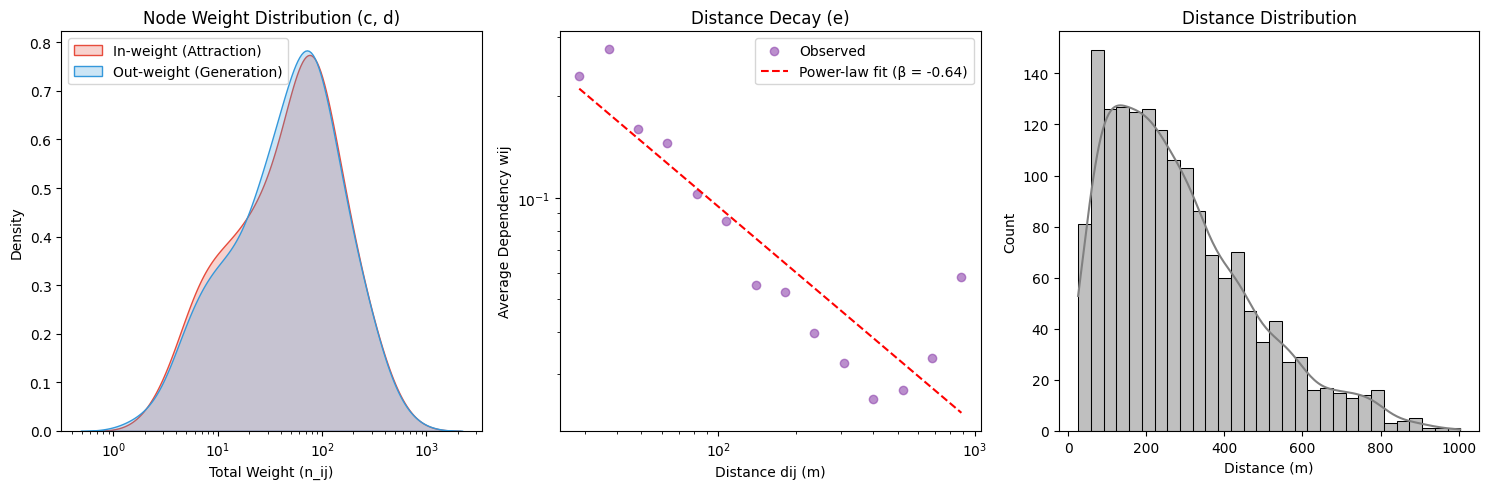

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
import pandas as pd

# --- 1. 计算地理距离函数 (Haversine) ---
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371 # 公里
    return c * r * 1000 # 米

# --- 2. 准备坐标数据 ---
# 确保 final_map_gdf 是 WGS84 坐标系
coords = final_map_gdf.to_crs(epsg=4326).copy()
coords['lat'] = coords.geometry.centroid.y
coords['lon'] = coords.geometry.centroid.x
coord_map = coords.set_index('SUPER_ID')[['lat', 'lon']].to_dict('index')

# --- 3. 计算每一对建筑的距离并准备绘图数据 ---
temp_net = dependence_network.copy()
def get_dist(row):
    u, v = row['SUPER_ID'], row['next_SUPER_ID']
    if u in coord_map and v in coord_map:
        return haversine(coord_map[u]['lon'], coord_map[u]['lat'],
                         coord_map[v]['lon'], coord_map[v]['lat'])
    return np.nan

temp_net['distance'] = temp_net.apply(get_dist, axis=1)

# --- 4. 开始绘图 (c, d, e) ---
plt.figure(figsize=(15, 5))

# [图 c & d]: 入权重 (In-weight) 与 出权重 (Out-weight) 分布
plt.subplot(1, 3, 1)
in_w = temp_net.groupby('next_SUPER_ID')['n_ij'].sum()
out_w = temp_net.groupby('SUPER_ID')['n_ij'].sum()

sns.kdeplot(in_w, label='In-weight (Attraction)', color='#E74C3C', fill=True, log_scale=True)
sns.kdeplot(out_w, label='Out-weight (Generation)', color='#3498DB', fill=True, log_scale=True)
plt.title('Node Weight Distribution (c, d)')
plt.xlabel('Total Weight (n_ij)')
plt.ylabel('Density')
plt.legend()

# 计算变异系数 (CV) 来验证论文结论
cv_in = in_w.std() / in_w.mean()
cv_out = out_w.std() / out_w.mean()
print(f"入权重变异系数 (CV_in): {cv_in:.2f}")
print(f"出权重变异系数 (CV_out): {cv_out:.2f}")

# [图 e]: 距离衰减效应 (Distance Decay)
plt.subplot(1, 3, 2)
# 过滤掉无效数据和距离为 0 的点
dist_df = temp_net[(temp_net['distance'] > 0) & (temp_net['w_ij'] > 0)].dropna(subset=['distance', 'w_ij'])

# 使用对数分桶 (Log-bins) 聚合数据
bins = np.logspace(np.log10(dist_df['distance'].min()), np.log10(dist_df['distance'].max()), 15)
dist_df['dist_bin'] = pd.cut(dist_df['distance'], bins=bins)

# 聚合每个桶的平均依赖强度
decay_data = dist_df.groupby('dist_bin', observed=True)['w_ij'].mean().reset_index()
# --- 修复核心：确保 bin_center 是浮点数 Numpy 数组 ---
decay_data['bin_center'] = decay_data['dist_bin'].apply(lambda x: x.mid).astype(float)
decay_data = decay_data.dropna()

# 绘制散点
plt.scatter(decay_data['bin_center'], decay_data['w_ij'], color='#8E44AD', alpha=0.6, label='Observed')

# 拟合幂律曲线: log(y) = log(a) + β*log(x)
log_x = np.log(decay_data['bin_center'])
log_y = np.log(decay_data['w_ij'])
slope, intercept = np.polyfit(log_x, log_y, 1)

# 绘制拟合线 (注意这里将 Series 显式转为 Numpy 以防报错)
x_fit = decay_data['bin_center'].values
y_fit = np.exp(intercept) * (x_fit ** slope)
plt.plot(x_fit, y_fit, 'r--', label=f'Power-law fit (β = {slope:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.title('Distance Decay (e)')
plt.xlabel('Distance dij (m)')
plt.ylabel('Average Dependency wij')
plt.legend()

# [补充]: 验证距离分布的直方图
plt.subplot(1, 3, 3)
sns.histplot(dist_df['distance'], bins=30, kde=True, color='gray')
plt.title('Distance Distribution')
plt.xlabel('Distance (m)')

plt.tight_layout()
plt.show()

In [53]:
# 专门检查入流和出流的原始统计
in_nodes = temp_net['next_SUPER_ID'].nunique()
out_nodes = temp_net['SUPER_ID'].nunique()

print(f"入流节点数: {in_nodes}, 出流节点数: {out_nodes}")
print(f"入流总流量: {in_w.sum()}, 出流总流量: {out_w.sum()}")

# 检查是否存在“全对称”：即每一个 A->B 都有一个对应的 B->A？
# 如果数据高度对称，CV 确实会趋同
reversed_check = temp_net.merge(
    temp_net,
    left_on=['SUPER_ID', 'next_SUPER_ID'],
    right_on=['next_SUPER_ID', 'SUPER_ID'],
    suffixes=('', '_rev')
)
print(f"对称转移占比: {len(reversed_check) / len(temp_net):.2%}")

入流节点数: 93, 出流节点数: 93
入流总流量: 7375, 出流总流量: 7375
对称转移占比: 78.75%


In [54]:
# --- 随机化验证 (Shuffle Test) ---
shuffled_net = temp_net.copy()

# 随机打乱建筑的 ID 对应关系（打破地理联系）
all_ids = list(coord_map.keys())
shuffled_ids = all_ids.copy()
np.random.shuffle(shuffled_ids)
id_shuffle_map = dict(zip(all_ids, shuffled_ids))

# 重新计算距离
def get_shuffled_dist(row):
    u = id_shuffle_map.get(row['SUPER_ID'])
    v = id_shuffle_map.get(row['next_SUPER_ID'])
    if u in coord_map and v in coord_map:
        return haversine(coord_map[u]['lon'], coord_map[u]['lat'],
                         coord_map[v]['lon'], coord_map[v]['lat'])
    return np.nan

shuffled_net['distance'] = shuffled_net.apply(get_shuffled_dist, axis=1)

# 重新计算随机化后的斜率
shuffled_dist_df = shuffled_net[(shuffled_net['distance'] > 0)].dropna(subset=['distance', 'w_ij'])
shuffled_bins = np.logspace(np.log10(shuffled_dist_df['distance'].min()), np.log10(shuffled_dist_df['distance'].max()), 15)
shuffled_dist_df['dist_bin'] = pd.cut(shuffled_dist_df['distance'], bins=shuffled_bins)
s_decay = shuffled_dist_df.groupby('dist_bin', observed=True)['w_ij'].mean().reset_index()
s_decay['bin_center'] = s_decay['dist_bin'].apply(lambda x: x.mid).astype(float)
s_decay = s_decay.dropna()

s_slope, _ = np.polyfit(np.log(s_decay['bin_center']), np.log(s_decay['w_ij']), 1)

print(f"\n--- 验证结果 ---")
print(f"原始斜率 (β): {slope:.4f}")
print(f"随机洗牌后斜率: {s_slope:.4f}")


--- 验证结果 ---
原始斜率 (β): -0.6438
随机洗牌后斜率: 0.0297


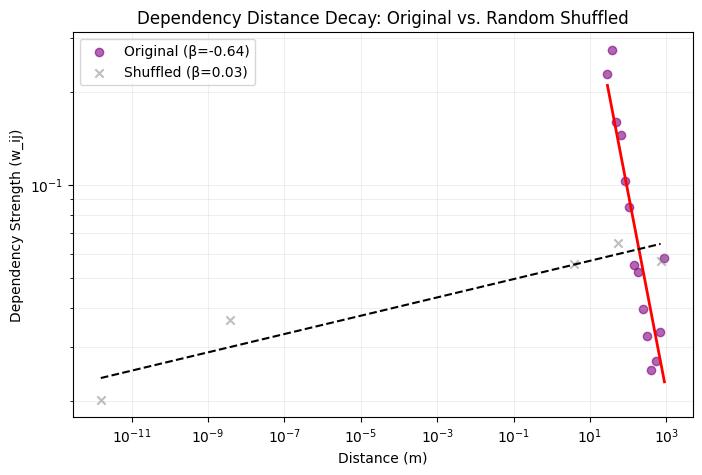

In [55]:
plt.figure(figsize=(8, 5))
# 原始数据
plt.scatter(decay_data['bin_center'], decay_data['w_ij'], color='purple', label=f'Original (β={slope:.2f})', alpha=0.6)
# 洗牌数据
plt.scatter(s_decay['bin_center'], s_decay['w_ij'], color='gray', marker='x', label=f'Shuffled (β={s_slope:.2f})', alpha=0.5)

# 拟合线
plt.plot(x_fit, y_fit, 'r-', linewidth=2)
plt.plot(s_decay['bin_center'], np.exp(np.polyfit(np.log(s_decay['bin_center']), np.log(s_decay['w_ij']), 1)[1]) * s_decay['bin_center']**s_slope, 'k--')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('Distance (m)'); plt.ylabel('Dependency Strength (w_ij)')
plt.title('Dependency Distance Decay: Original vs. Random Shuffled')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [56]:
def compare_cv_before_after(raw_transitions, filtered_transitions):
    results = []

    for name, df in [("Raw (71,322)", raw_transitions), ("Filtered (7,375)", filtered_transitions)]:
        # 计算入和出
        in_w = df.groupby('next_building' if 'next_building' in df.columns else 'next_SUPER_ID')['SUPER_ID'].count()
        out_w = df.groupby('SUPER_ID')['SUPER_ID'].count()

        cv_in = in_w.std() / in_w.mean()
        cv_out = out_w.std() / out_w.mean()

        results.append({
            "Dataset": name,
            "CV_In (Attraction)": cv_in,
            "CV_Out (Generation)": cv_out,
            "Nodes": df['SUPER_ID'].nunique()
        })

    return pd.DataFrame(results)

# 执行对比
# 注意：这里的 transition_sequences 是你之前没过滤 A->A 时的完整 7.1w 条数据
cv_comparison = compare_cv_before_after(transition_sequences, within_24h_transitions)
print(cv_comparison)

            Dataset  CV_In (Attraction)  CV_Out (Generation)  Nodes
0      Raw (71,322)            1.381412             1.372079    111
1  Filtered (7,375)            1.139692             1.094537     93


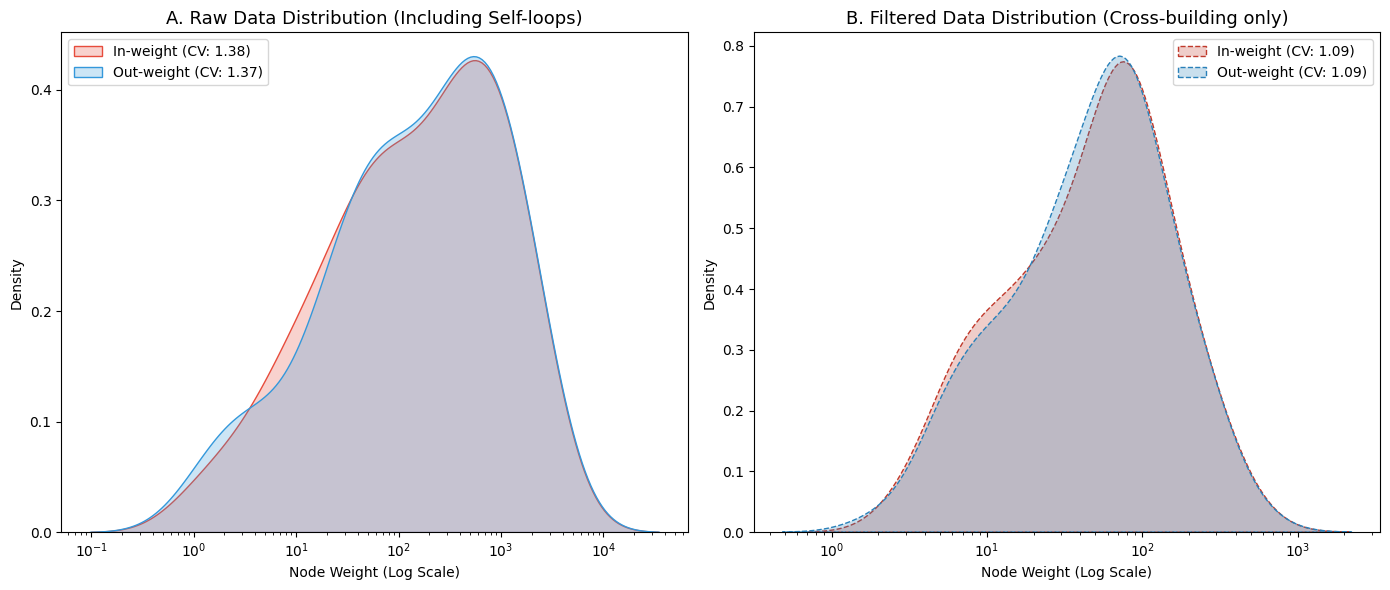

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_node_weight_comparison(raw_df, filtered_df):
    plt.figure(figsize=(14, 6))

    # --- 左图：Raw Data (71,322) ---
    plt.subplot(1, 2, 1)
    # 计算原始数据的入/出权重
    raw_in = raw_df.groupby('next_building' if 'next_building' in raw_df.columns else 'next_SUPER_ID').size()
    raw_out = raw_df.groupby('SUPER_ID').size()

    sns.kdeplot(raw_in, label=f'In-weight (CV: {raw_in.std()/raw_in.mean():.2f})', color='#E74C3C', fill=True, log_scale=True)
    sns.kdeplot(raw_out, label=f'Out-weight (CV: {raw_out.std()/raw_out.mean():.2f})', color='#3498DB', fill=True, log_scale=True)

    plt.title('A. Raw Data Distribution (Including Self-loops)', fontsize=13)
    plt.xlabel('Node Weight (Log Scale)')
    plt.ylabel('Density')
    plt.legend()

    # --- 右图：Filtered Data (7,375) ---
    plt.subplot(1, 2, 2)
    # 计算脱水后的入/出权重
    filt_in = filtered_df.groupby('next_SUPER_ID').size()
    filt_out = filtered_df.groupby('SUPER_ID').size()

    sns.kdeplot(filt_in, label=f'In-weight (CV: {filt_in.std()/filt_in.mean():.2f})', color='#C0392B', linestyle='--', fill=True, log_scale=True)
    sns.kdeplot(filt_out, label=f'Out-weight (CV: {filt_out.std()/filt_out.mean():.2f})', color='#2980B9', linestyle='--', fill=True, log_scale=True)

    plt.title('B. Filtered Data Distribution (Cross-building only)', fontsize=13)
    plt.xlabel('Node Weight (Log Scale)')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

# 执行绘图
# 请确保你的变量名与之前一致：transition_sequences (原始) 和 within_24h_transitions (过滤后)
plot_node_weight_comparison(transition_sequences, within_24h_transitions)

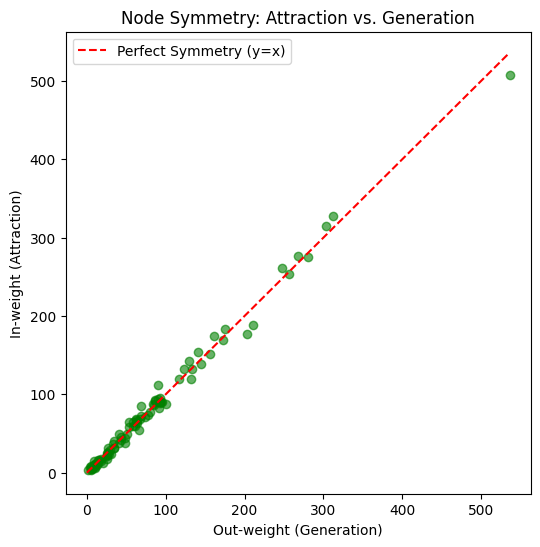

In [58]:
plt.figure(figsize=(6, 6))
plt.scatter(out_w, in_w, alpha=0.6, color='green')
# 画一条 y=x 的参考线
max_val = max(out_w.max(), in_w.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Symmetry (y=x)')

plt.xlabel('Out-weight (Generation)')
plt.ylabel('In-weight (Attraction)')
plt.title('Node Symmetry: Attraction vs. Generation')
plt.legend()
plt.show()

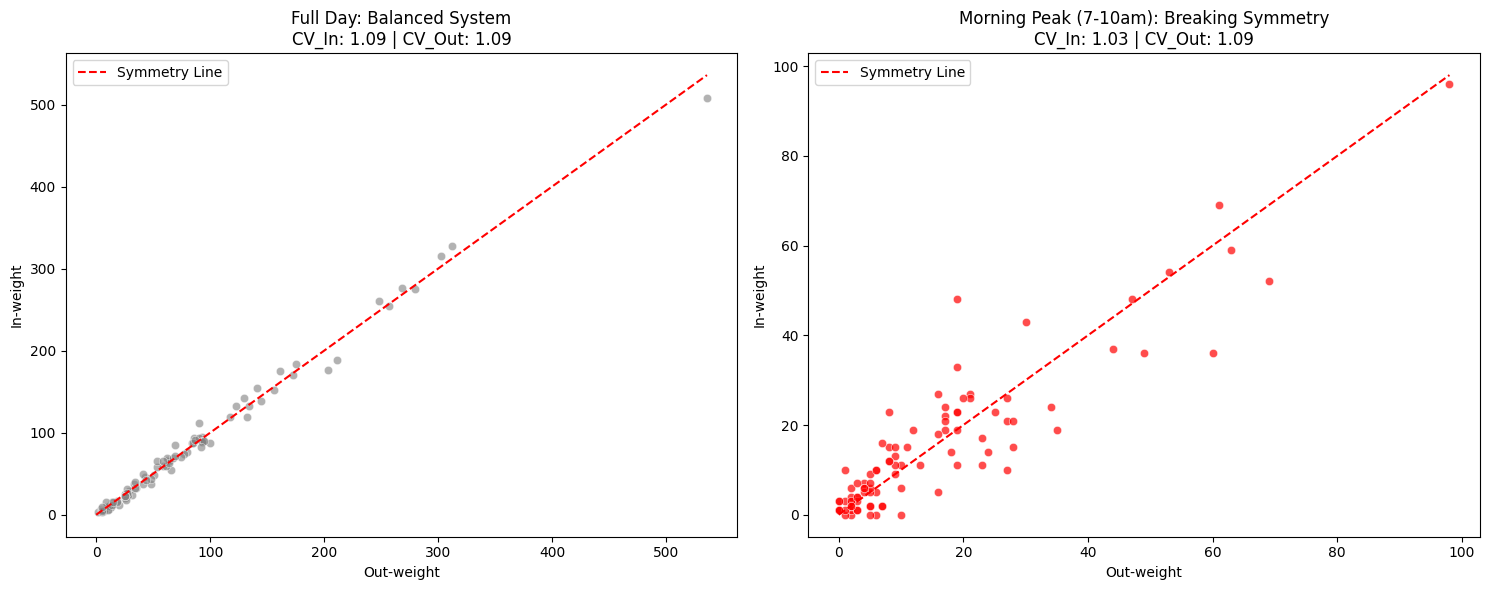

早高峰 In-weight 变异系数: 1.03
早高峰 Out-weight 变异系数: 1.09


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_time_window_symmetry(df, window_name, start_hour, end_hour):
    # 1. 提取特定时间段的转移 (以到达目的地的时间 next_start_ts 为准)
    # 假设你的 next_start_ts 已经是 datetime 格式
    mask = (df['next_start_ts'].dt.hour >= start_hour) & (df['next_start_ts'].dt.hour < end_hour)
    sub_df = df[mask].copy()

    # 2. 计算该时段的入流和出流
    in_w = sub_df.groupby('next_SUPER_ID').size()
    out_w = sub_df.groupby('SUPER_ID').size()

    # 3. 对齐节点，确保每个节点在散点图中都有坐标
    all_nodes = list(set(in_w.index) | set(out_w.index))
    plot_df = pd.DataFrame(index=all_nodes)
    plot_df['In-weight'] = in_w
    plot_df['Out-weight'] = out_w
    plot_df = plot_df.fillna(0)

    cv_in = in_w.std() / in_w.mean() if len(in_w)>0 else 0
    cv_out = out_w.std() / out_w.mean() if len(out_w)>0 else 0

    return plot_df, cv_in, cv_out

# --- 执行分析 ---
# 1. 早高峰 (7 AM - 10 AM): 应该是“强吸引”模式
df_morning, cv_in_m, cv_out_m = analyze_time_window_symmetry(within_24h_transitions, "Morning Peak", 7, 10)

# 2. 全天 (0 AM - 23 PM): 应该是“平衡”模式
df_all, cv_in_a, cv_out_a = analyze_time_window_symmetry(within_24h_transitions, "Full Day", 0, 24)

# --- 绘图对比 ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 图 1: 全天对称性
sns.scatterplot(data=df_all, x='Out-weight', y='In-weight', alpha=0.6, ax=axes[0], color='gray')
axes[0].plot([0, df_all.max().max()], [0, df_all.max().max()], 'r--', label='Symmetry Line')
axes[0].set_title(f'Full Day: Balanced System\nCV_In: {cv_in_a:.2f} | CV_Out: {cv_out_a:.2f}')
axes[0].legend()

# 图 2: 早高峰非对称性
sns.scatterplot(data=df_morning, x='Out-weight', y='In-weight', alpha=0.7, ax=axes[1], color='red')
axes[1].plot([0, df_morning.max().max()], [0, df_morning.max().max()], 'r--', label='Symmetry Line')
axes[1].set_title(f'Morning Peak (7-10am): Breaking Symmetry\nCV_In: {cv_in_m:.2f} | CV_Out: {cv_out_m:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"早高峰 In-weight 变异系数: {cv_in_m:.2f}")
print(f"早高峰 Out-weight 变异系数: {cv_out_m:.2f}")

In [60]:
# 看看早高峰谁是真正的“黑洞”
df_morning['net_gain'] = df_morning['In-weight'] - df_morning['Out-weight']
top_sinks = df_morning.sort_values(by='net_gain', ascending=False).head(5)

print("--- 早高峰最强的‘人流黑洞’（只进不出） ---")
print(top_sinks[['In-weight', 'Out-weight', 'net_gain']])

--- 早高峰最强的‘人流黑洞’（只进不出） ---
                     In-weight  Out-weight  net_gain
226-222@4hh-ztn-qxq       48.0        19.0      29.0
zzy-223@4hh-ztn-nnq       23.0         8.0      15.0
223-222@4hh-ztp-59f       33.0        19.0      14.0
222-224@4hh-ztn-sh5       43.0        30.0      13.0
222-223@4hh-ztn-py9       27.0        16.0      11.0
